# H-CAST Output Analysis

This notebook analyzes seeded training/test artifacts in `/scratch/g.saggini1/outputs/`. Each experiment is a parent directory containing `seed_<seed>` runs; curves and final metrics report the mean and sample standard deviation across those seeds.

It compares:

- H-CAST global-KL and no-KL baselines: `hcast_<dataset>` and `hcast_<dataset>_nokl`
- the HCC arm: `hcast_<dataset>_hcc` (HCC is a binary on/off switch, active for the whole run)
- lexicographic variants: `hcast_<dataset>_lex_{coarse_first,fine_first}`

It includes:
- validation curves for `fpa_topdown` and `weighted_ap_topdown`,
- per-level validation top-down accuracy curves,
- a final test comparison table with deltas,
- projection diagnostics (`proj_constraint_alpha`, `proj_constraint_strength`, `proj_temperature`, etc.),
- short interpretation snippets after each analysis block.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'configs').is_dir()), cwd)
notebook_utils_dir = repo_root / 'notebooks' / 'utils'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import HCastAnalysis, HCastAnalysisConfig, resolve_project_root

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [2]:
INCLUDE_BASELINES = True
INCLUDE_TOPDOWN_METRICS = True
BASELINE_COLOR = '#243ab4'

DATASET_SLUGS = {
    'cifar-100': 'cifar100',
    'cub-200-2011': 'cub200',
    'fgvc-aircraft': 'aircraft',
}
HCAST_DATASETS = tuple(DATASET_SLUGS.values())

BASELINE_BY_DATASET = {
    dataset_key: {'run_dir': f'hcast_{dataset}', 'label': 'H-CAST global KL'}
    for dataset_key, dataset in DATASET_SLUGS.items()
}


MANUAL_RUNS = [
    # # No-KL H-CAST baselines
    # *[
    #     {'run_dir': f'hcast_{dataset}_nokl', 'label': 'H-CAST no global KL'}
    #     for dataset in HCAST_DATASETS
    # ],

    # HCC arm: a binary on/off switch, active for the whole run, launched by
    # scripts/hcast/run_hcast_hcc.sh on top of the plain baseline config, so it
    # keeps global KL and differs from the baseline in HCC alone.
    *[
        {'run_dir': f'hcast_{dataset}_hcc', 'label': 'H-CAST HCC'}
        for dataset in HCAST_DATASETS
    ],

    # Gradient-space lexicographic H-CAST variants
    *[
        {'run_dir': f'hcast_{dataset}_lex_{mode}',
            'label': f'H-CAST lex {mode}'}
        for dataset in HCAST_DATASETS
        for mode in ('coarse_first', 'fine_first')
    ],

]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]


In [3]:
config = HCastAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    include_topdown_metrics=INCLUDE_TOPDOWN_METRICS,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HCastAnalysis.from_config(config)
analysis.print_run_summary()


[cifar-100] H-CAST global KL: epochs=100, best_td_epoch=92.33333333333333, best_ind_epoch=97.33333333333333, baseline, seeds=[0, 1, 2]
[cifar-100] H-CAST HCC: epochs=100, best_td_epoch=99.33333333333333, best_ind_epoch=97.66666666666667, seeds=[0, 1, 2]
[cifar-100] H-CAST lex coarse_first: epochs=100, best_td_epoch=98.66666666666667, best_ind_epoch=98.66666666666667, seeds=[0, 1, 2]
[cub-200-2011] H-CAST global KL: epochs=100, best_td_epoch=82.66666666666667, best_ind_epoch=82.66666666666667, baseline, seeds=[0, 1, 2]
[cub-200-2011] H-CAST HCC: epochs=100, best_td_epoch=87.33333333333333, best_ind_epoch=93.0, seeds=[0, 1, 2]
[cub-200-2011] H-CAST lex coarse_first: epochs=100, best_td_epoch=77.0, best_ind_epoch=88.33333333333333, seeds=[0, 1, 2]
[fgvc-aircraft] H-CAST global KL: epochs=100, best_td_epoch=88.0, best_ind_epoch=91.66666666666667, baseline, seeds=[0, 1, 2]
[fgvc-aircraft] H-CAST HCC: epochs=100, best_td_epoch=71.66666666666667, best_ind_epoch=79.66666666666667, seeds=[0, 1,

## H-CAST Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- color = run
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, `TICE`, and `AHD`.


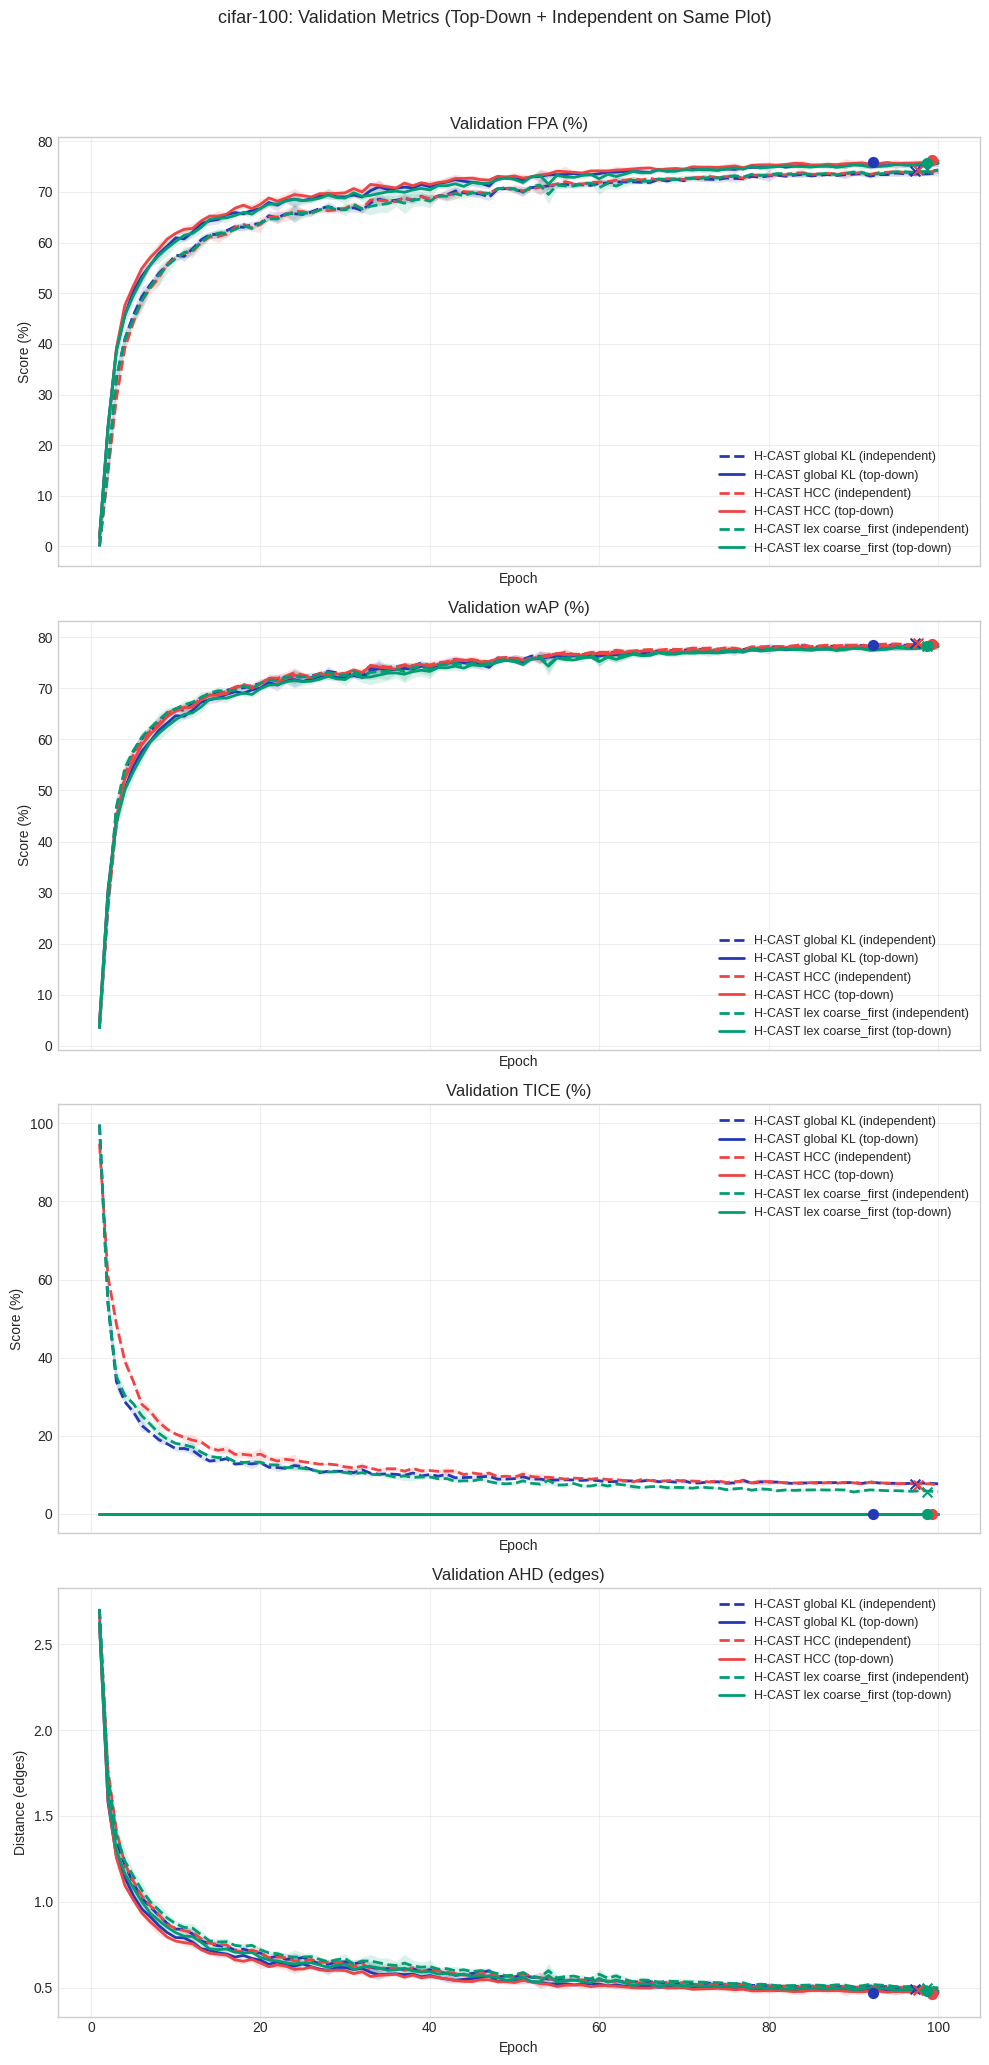

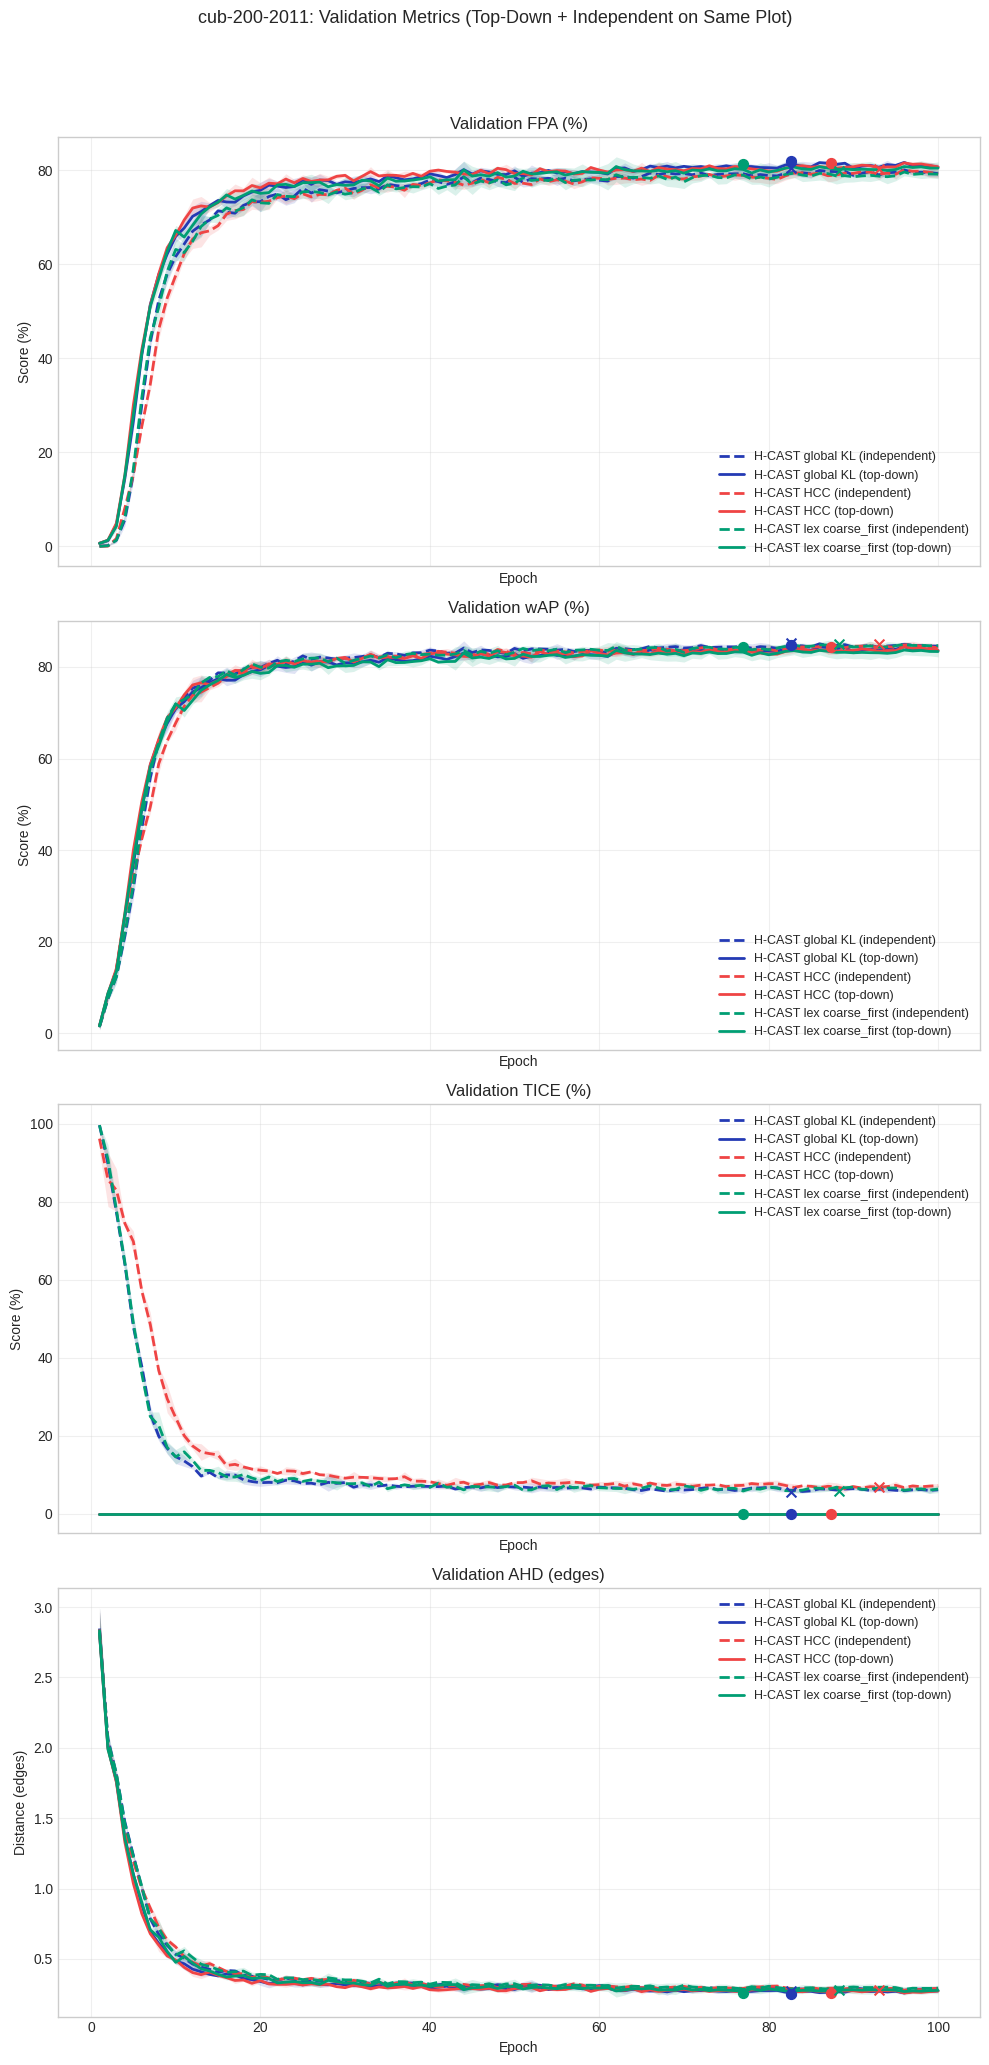

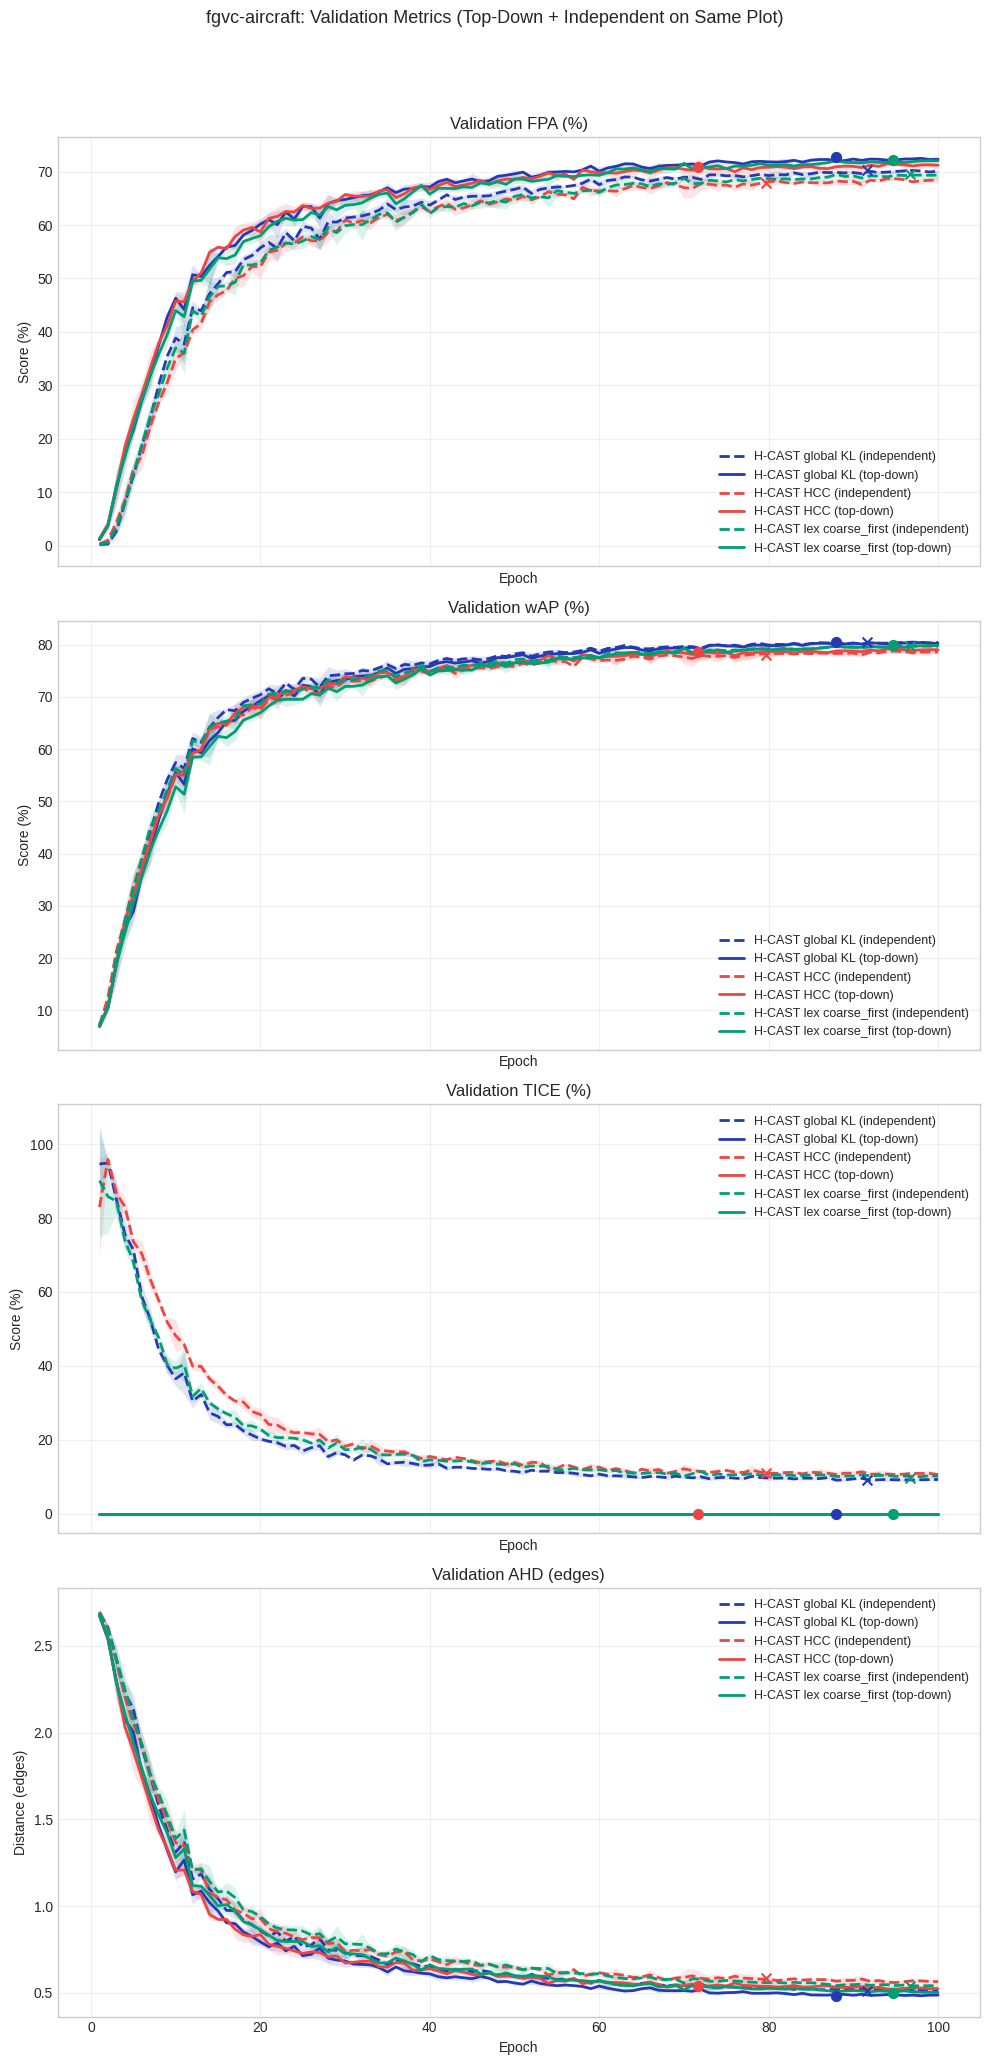

In [4]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Projection Diagnostics (HCC)

This section visualizes projection diagnostics logged in `val_metrics` (when available):
- `proj_constraint_alpha` (annealing blend/schedule value),
- `proj_constraint_strength` (intrinsic projection strength),
- `proj_temperature`,
- `proj_mode_intrinsic_soft`.


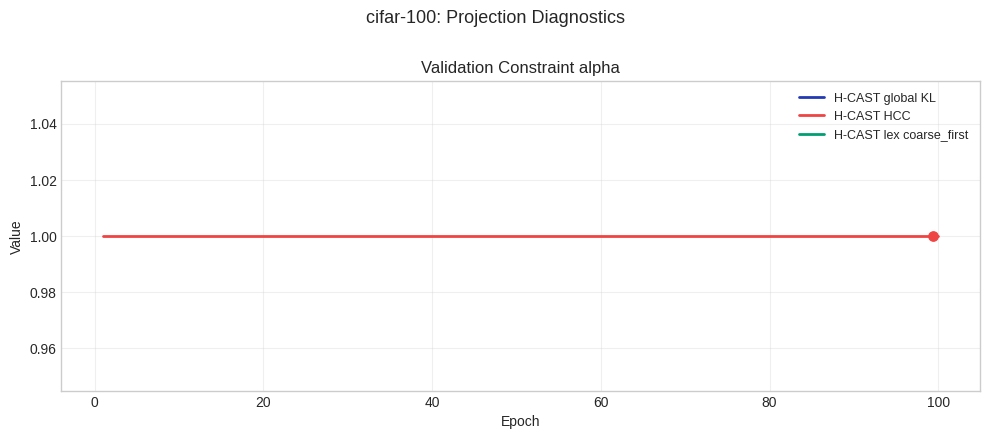

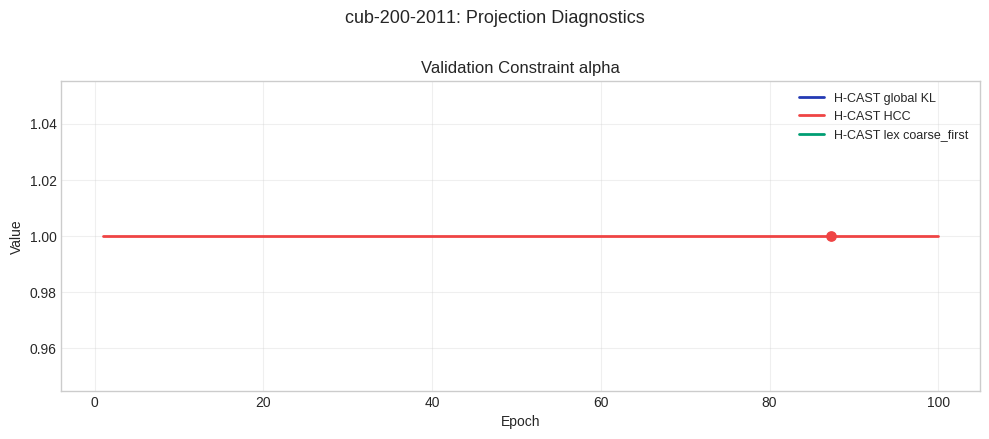

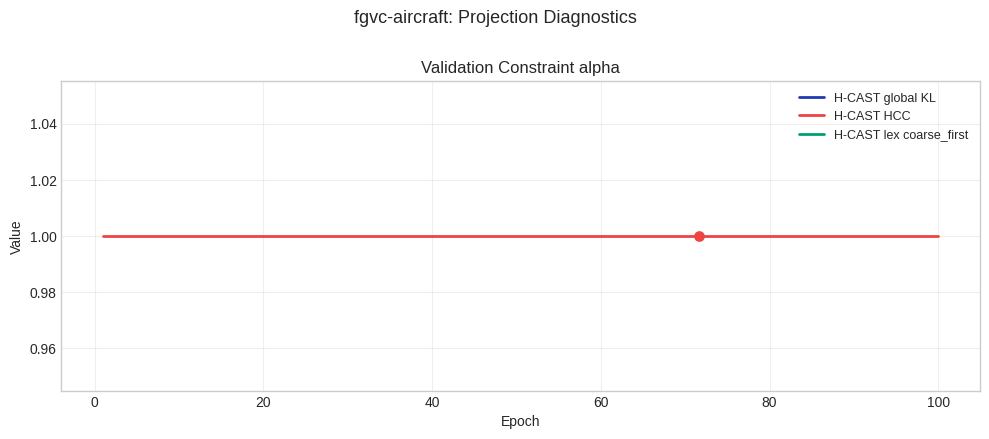

In [5]:
analysis.plot_projection_diagnostics()


## Training Loss Comparison

This section compares training losses between runs for both aggregate losses (`total`, `level_ce`, `gk_loss`) and per-level losses (`loss_level_*`).

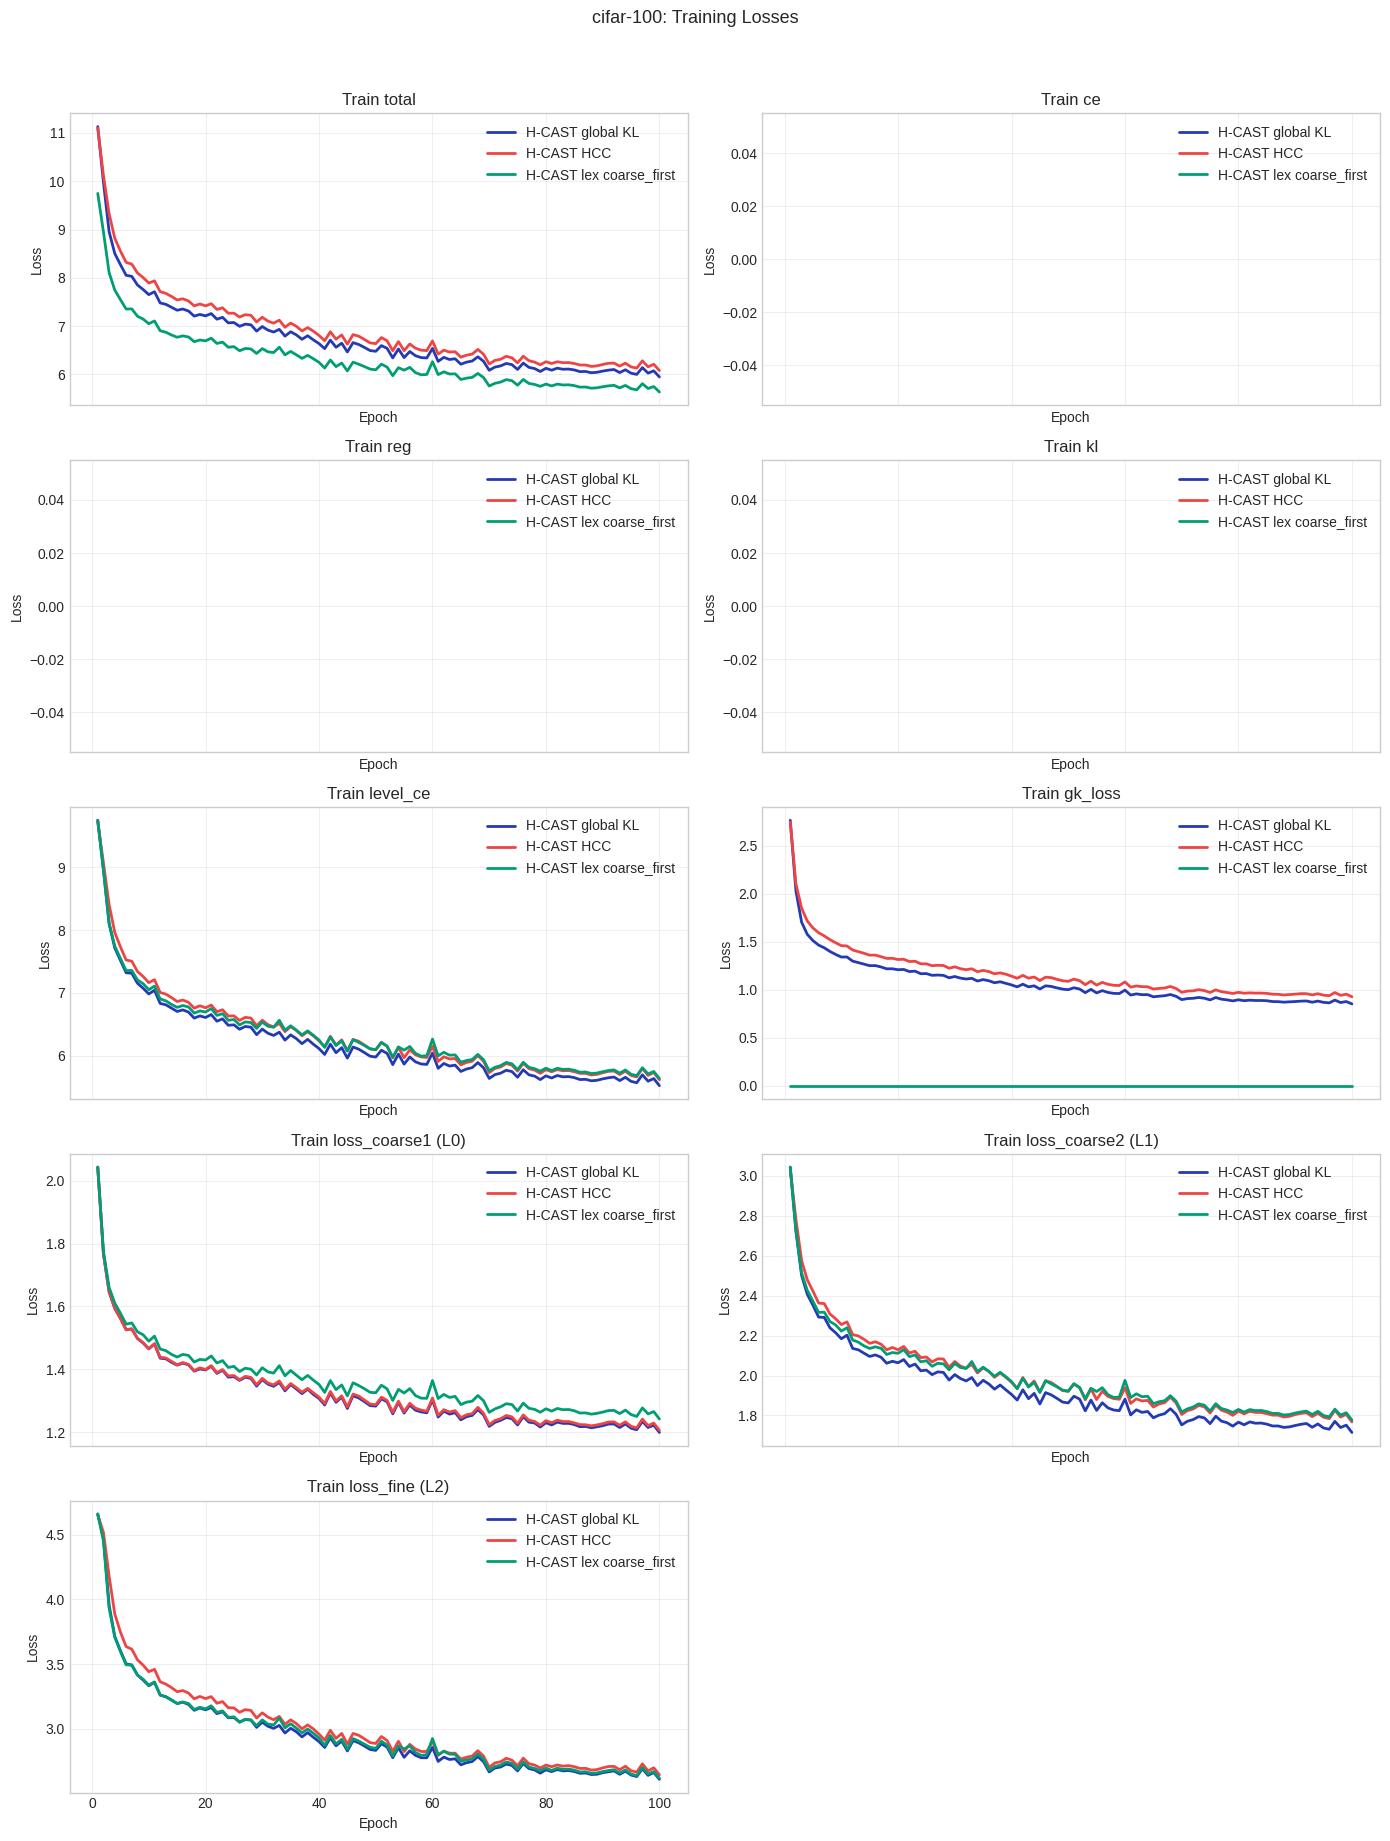

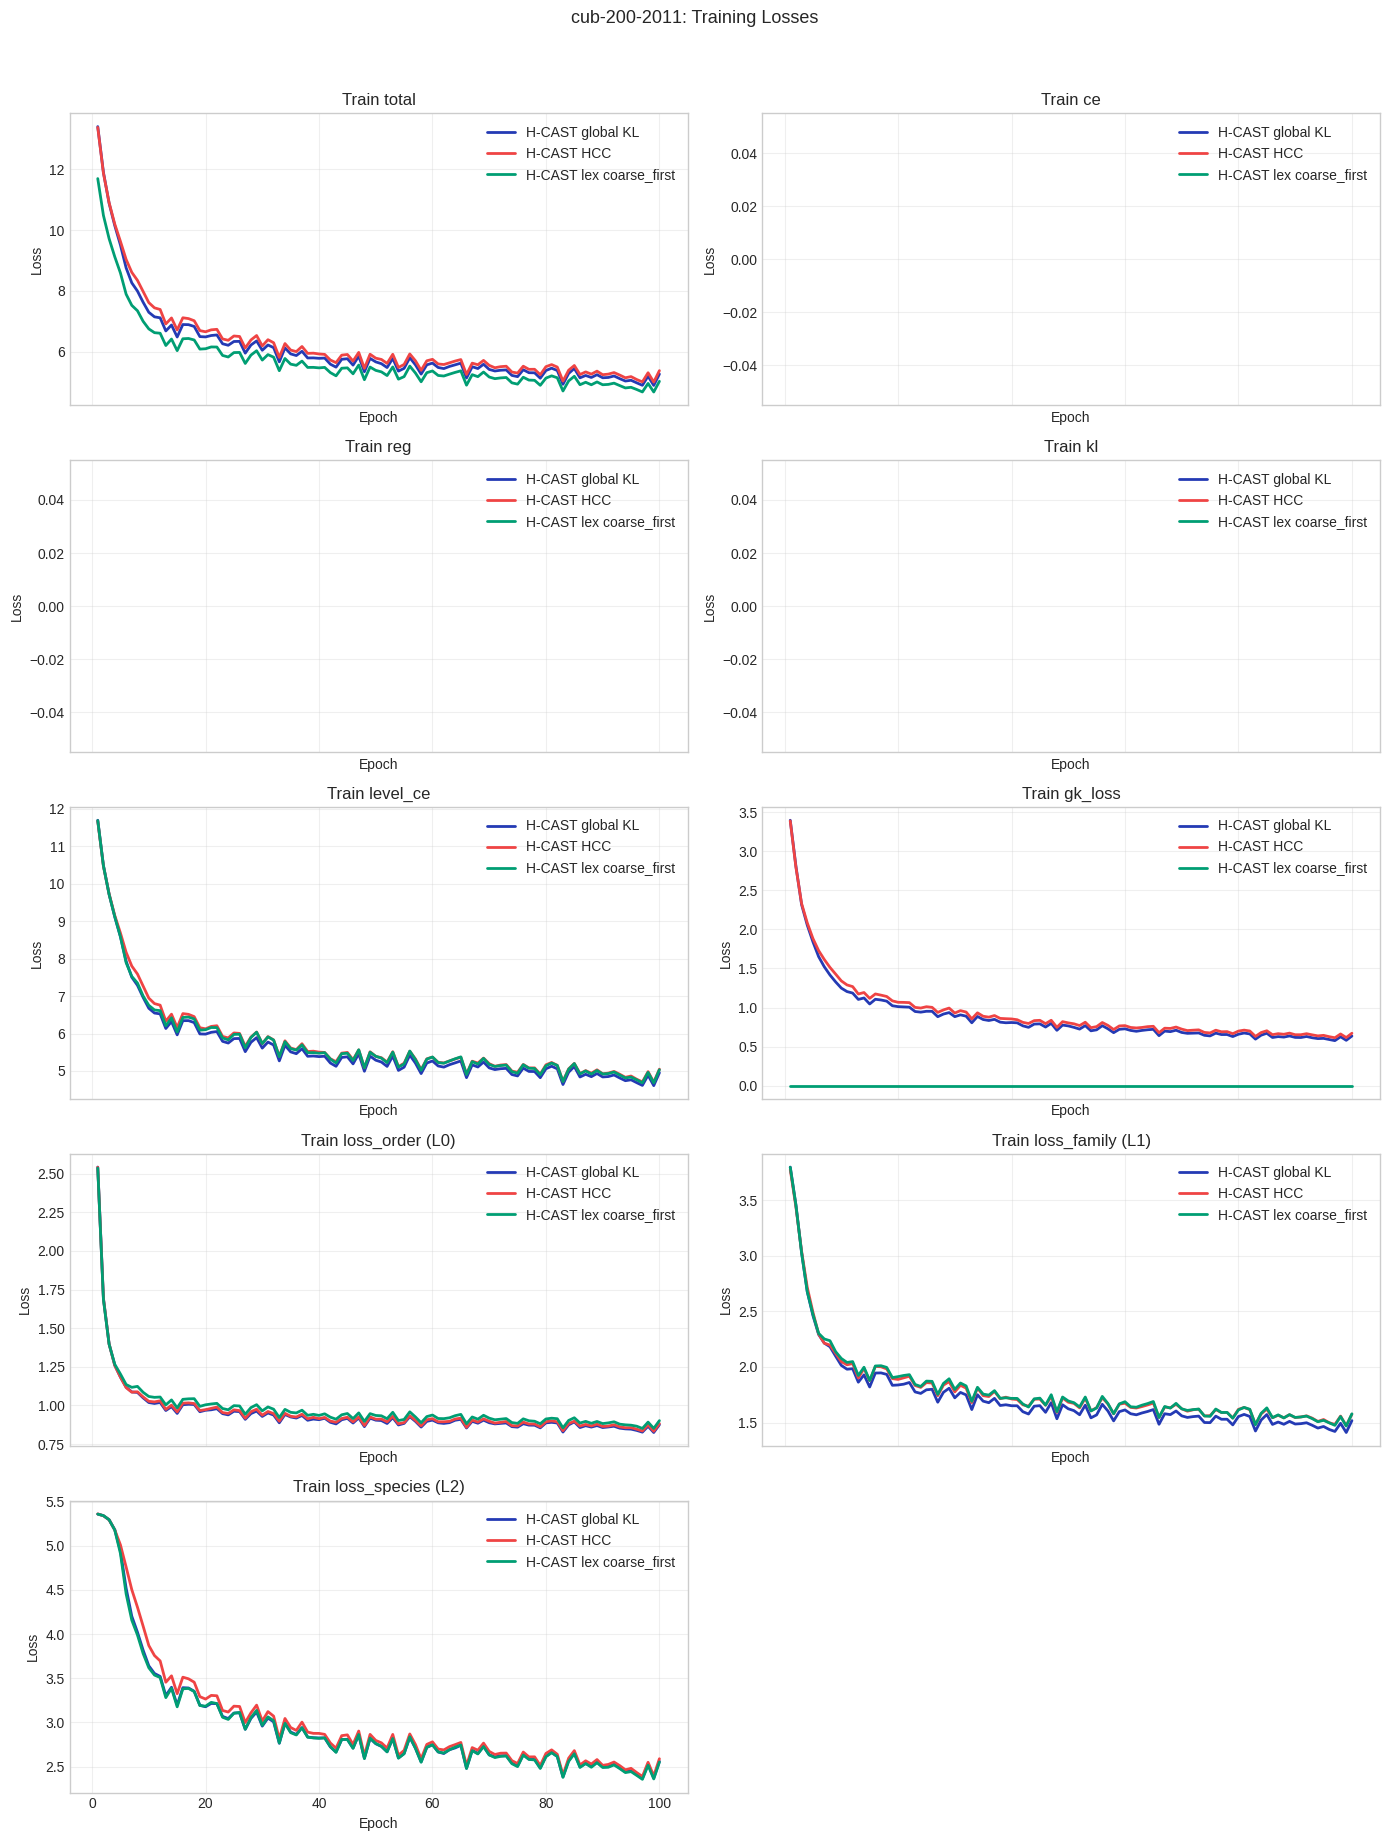

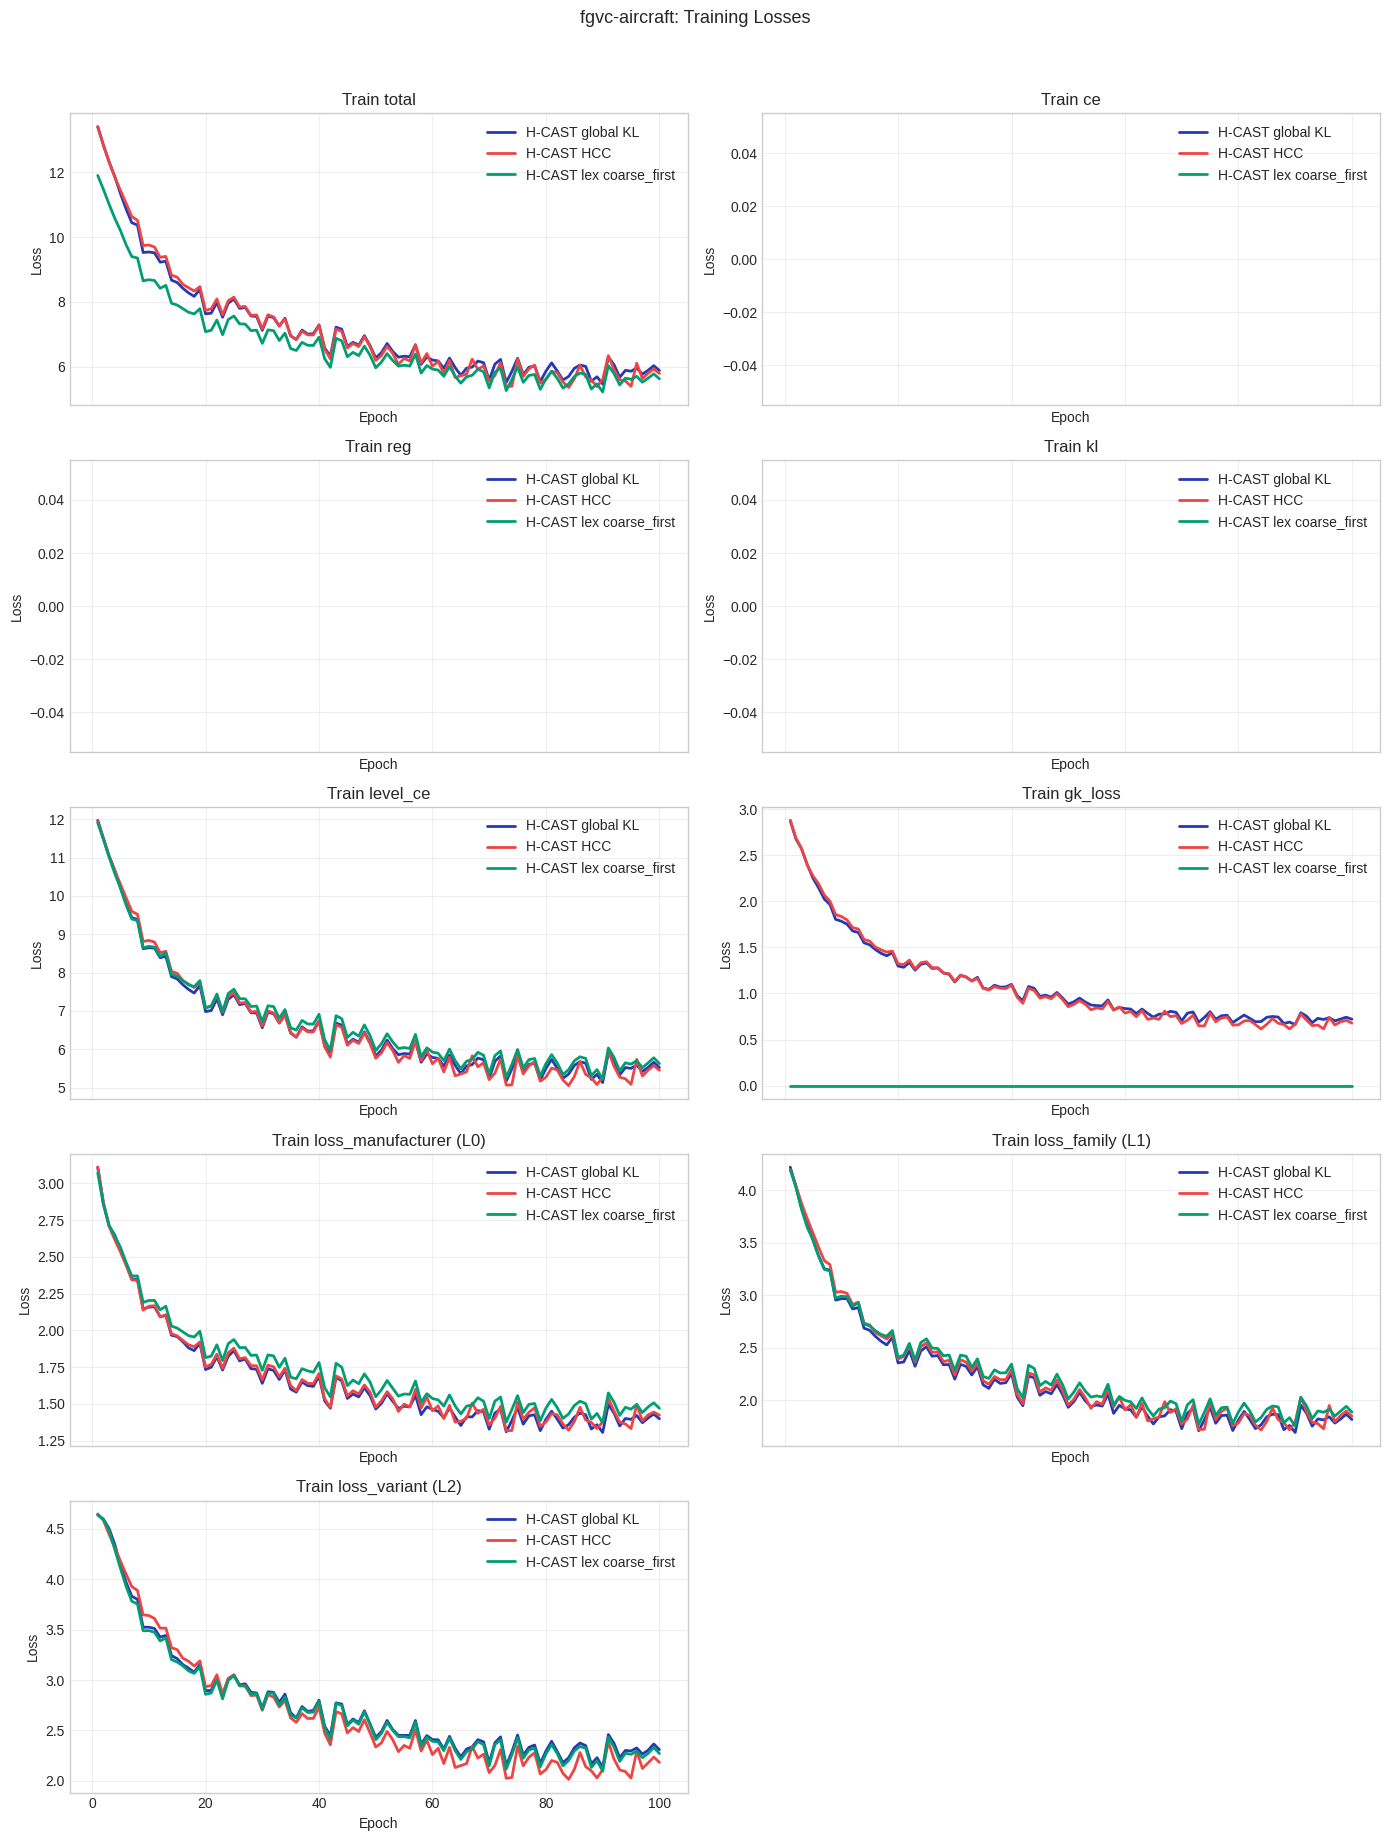

In [6]:
analysis.plot_training_losses()


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Run Per-Level Training Losses (Per Dataset)

Interpretation note:
- Each chart corresponds to one selected run in its dataset section.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).



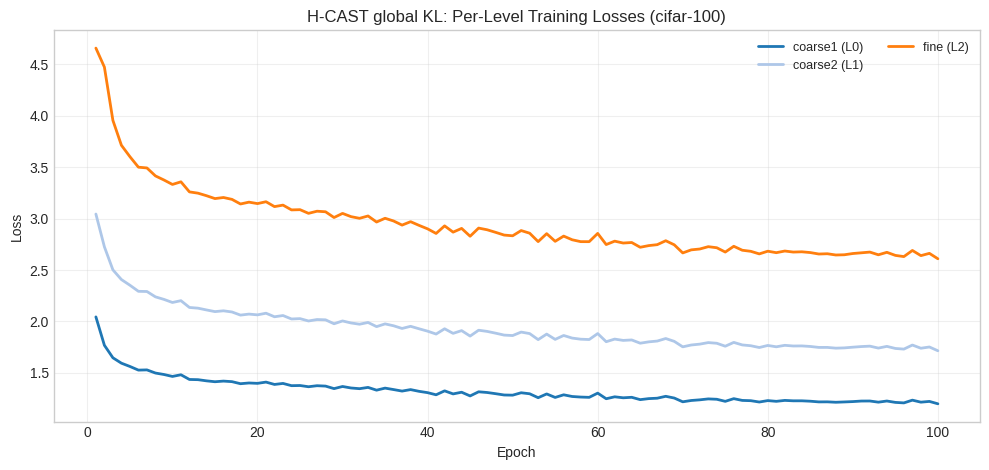

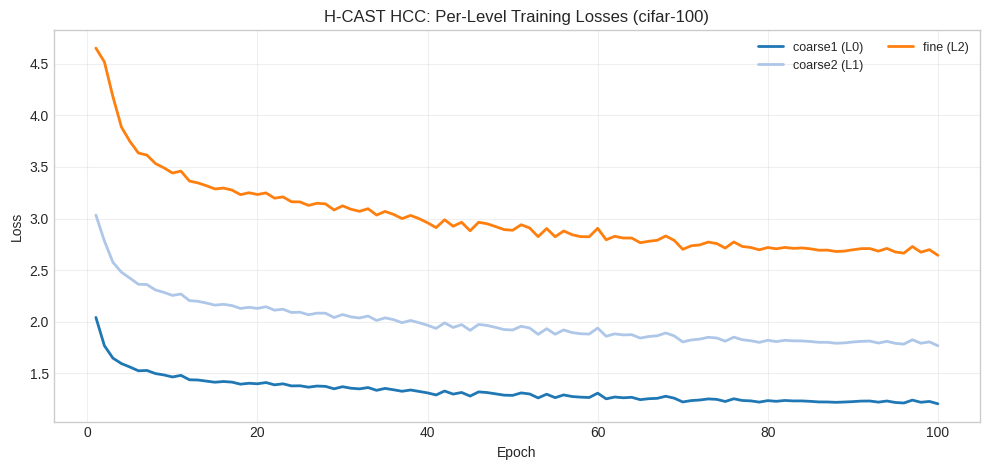

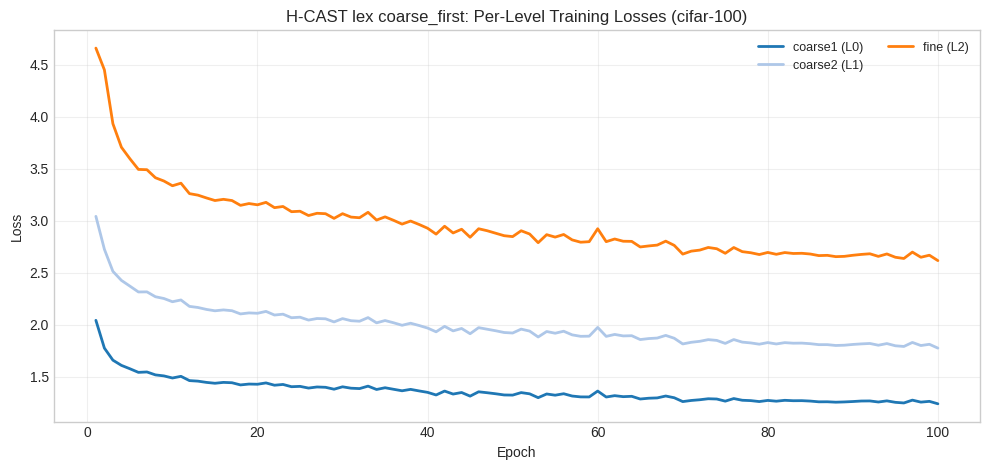

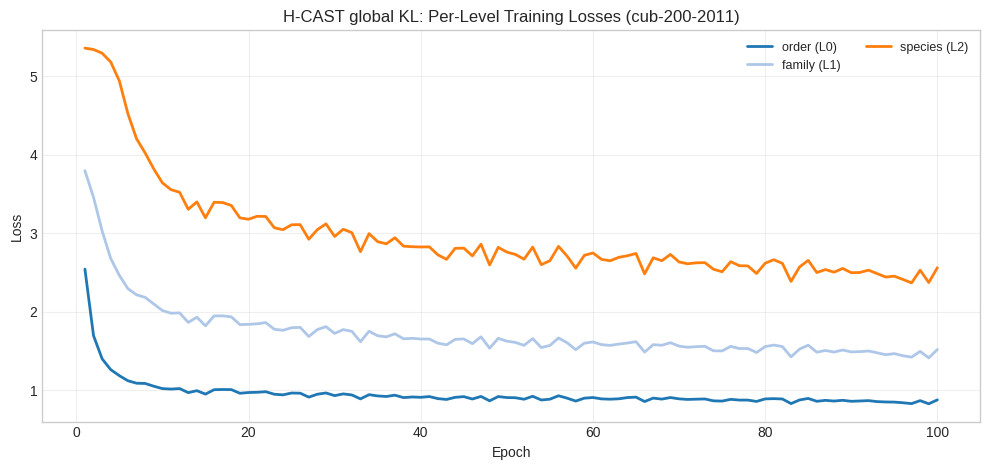

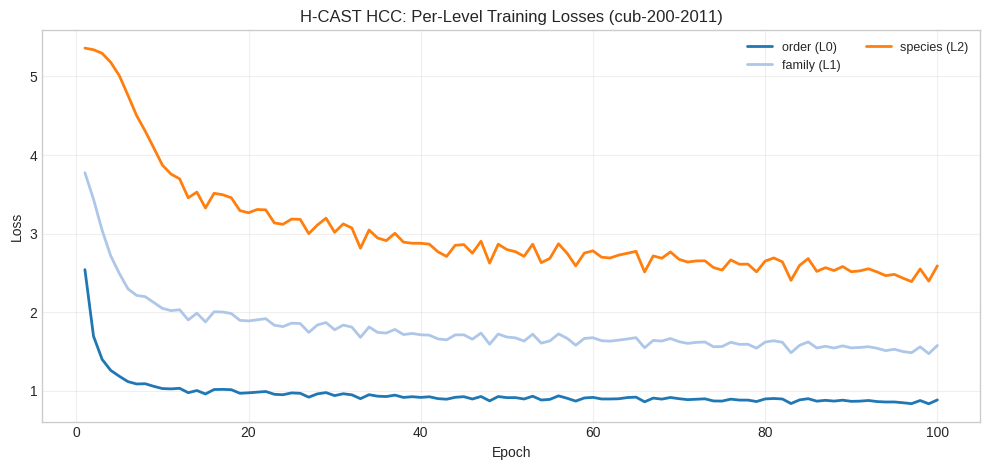

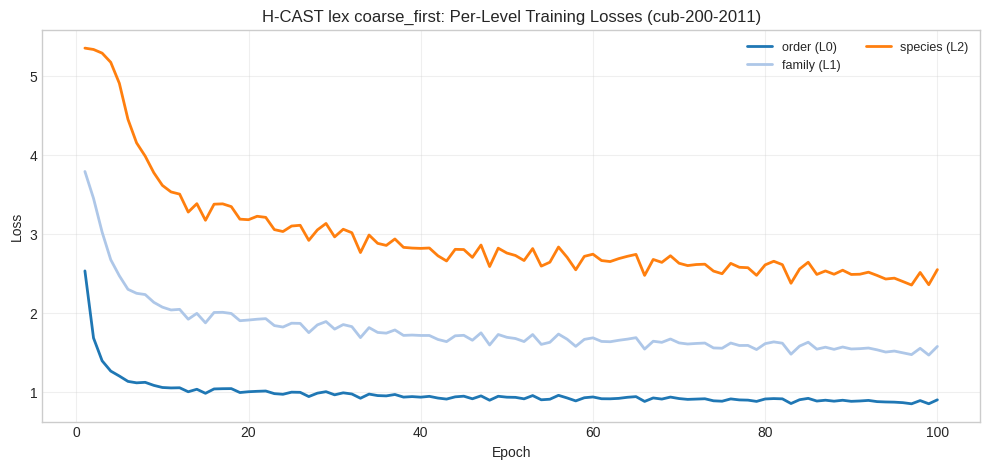

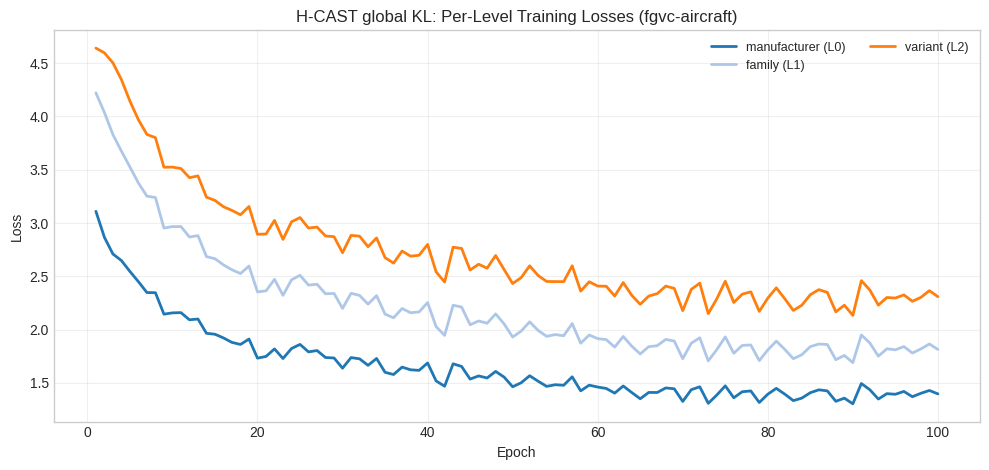

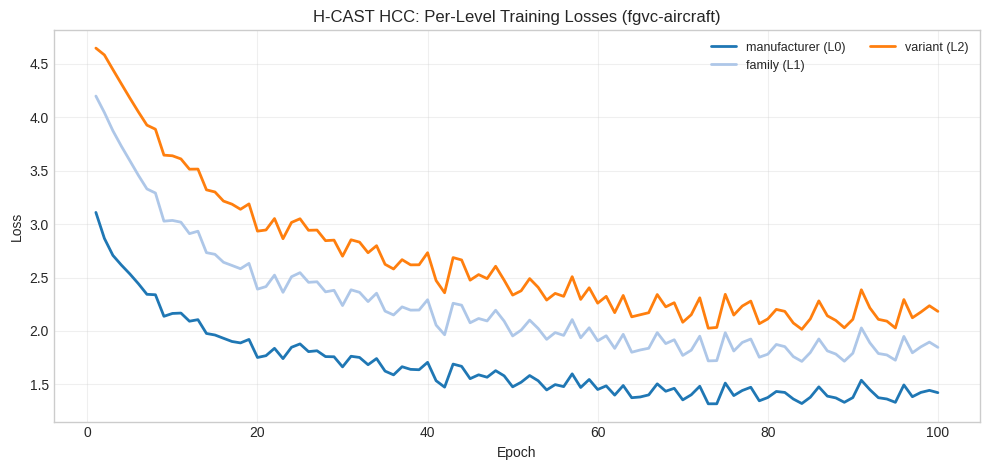

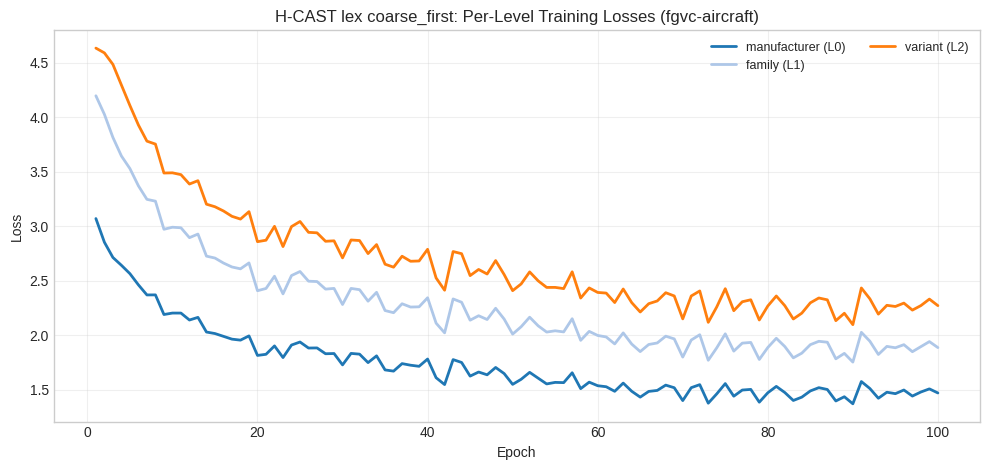

In [7]:
analysis.plot_per_run_per_level_training_losses()


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and lexicographic projection diagnostics stored in `train_metrics` for each epoch.

- Standard views are organized by subsets: `t3t2t1`, `t3`, `t2t1`, `t2`, and `t1`.
- Pre-gradient norms include:
  - `t3t2t1`: coarse
  - `t3`: coarse
  - `t2t1`: coarse, mid
  - `t2`: coarse, mid
  - `t1`: coarse, mid, fine
- Gradient cosines shown: `cos_mid_coarse`, `cos_fine_coarse`, `cos_fine_mid` (pairwise, trunk-agnostic overlaps).
- Parameter norms/movement are shown on the same trunk subsets (`t3t2t1/t3/t2t1/t2/t1`).
- In lex mode, `post_grad_*` mirrors pre-gradient keys and a dedicated pre-vs-post overlay is plotted.


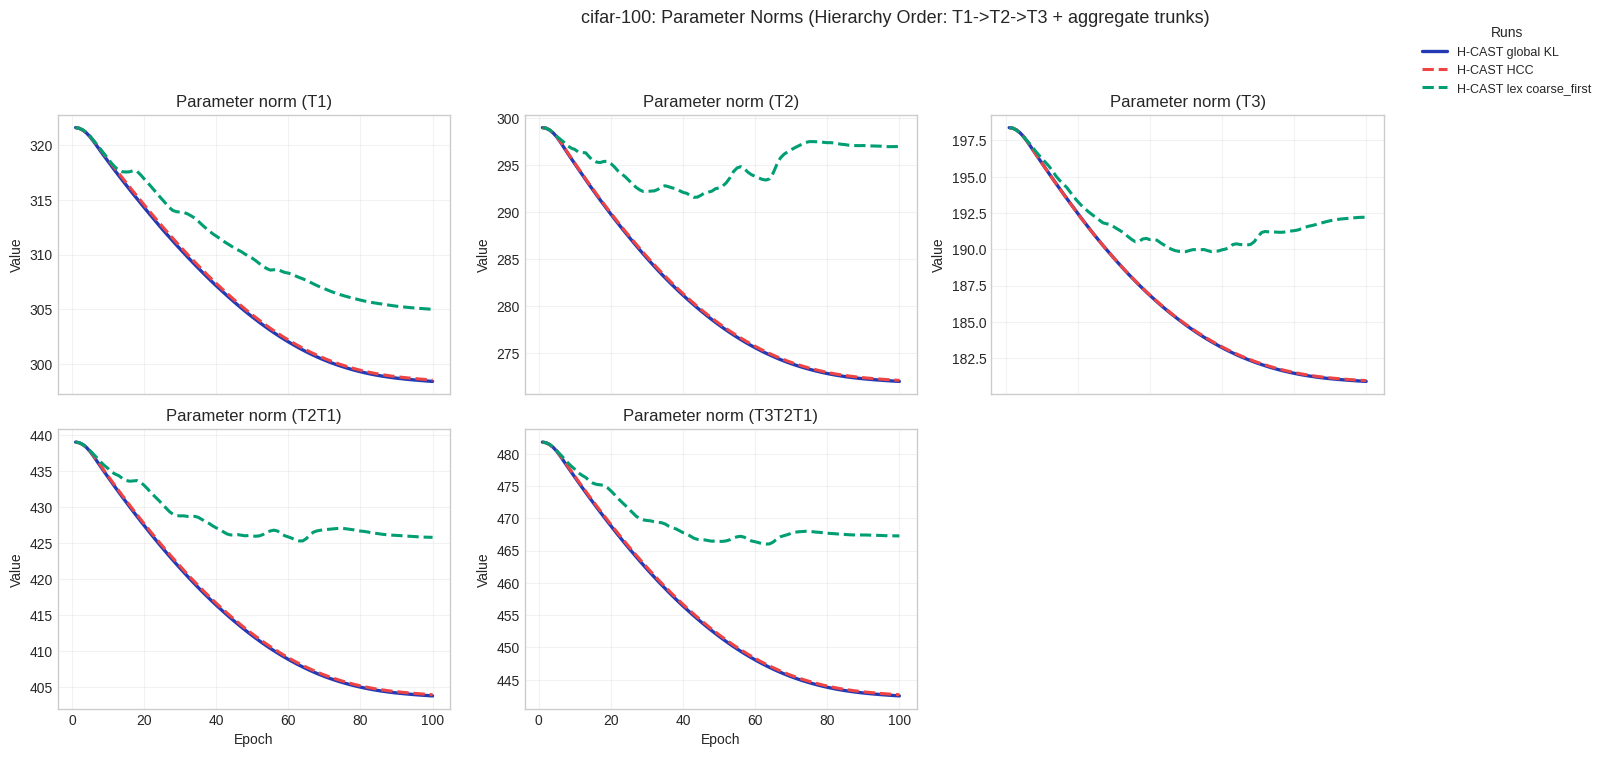

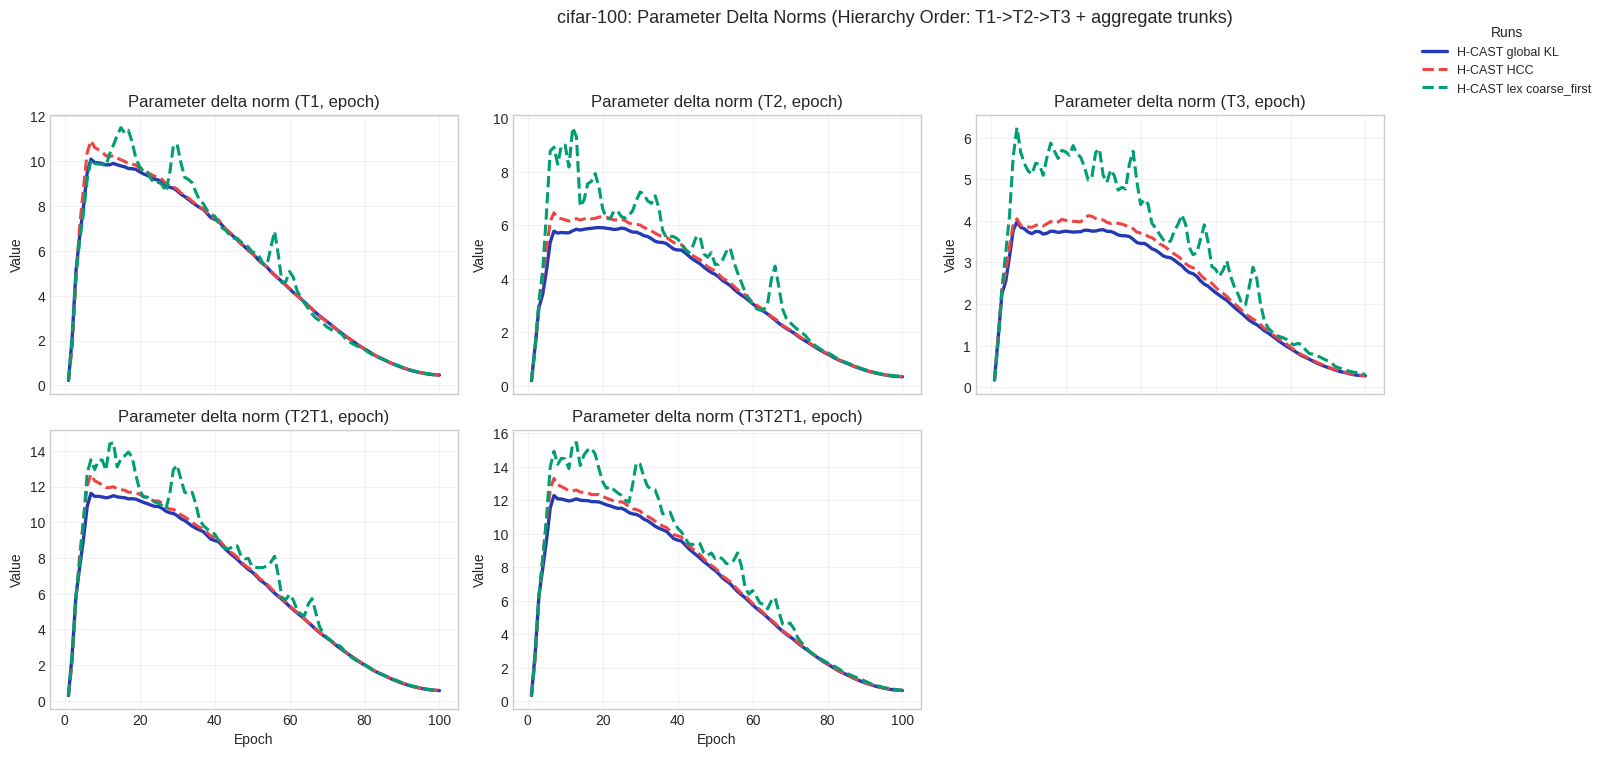

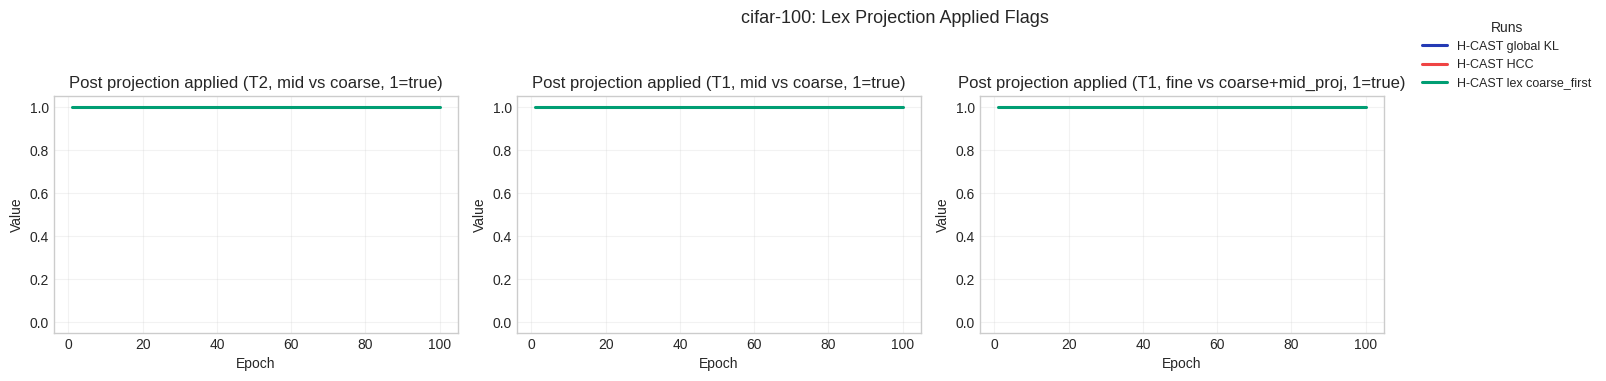

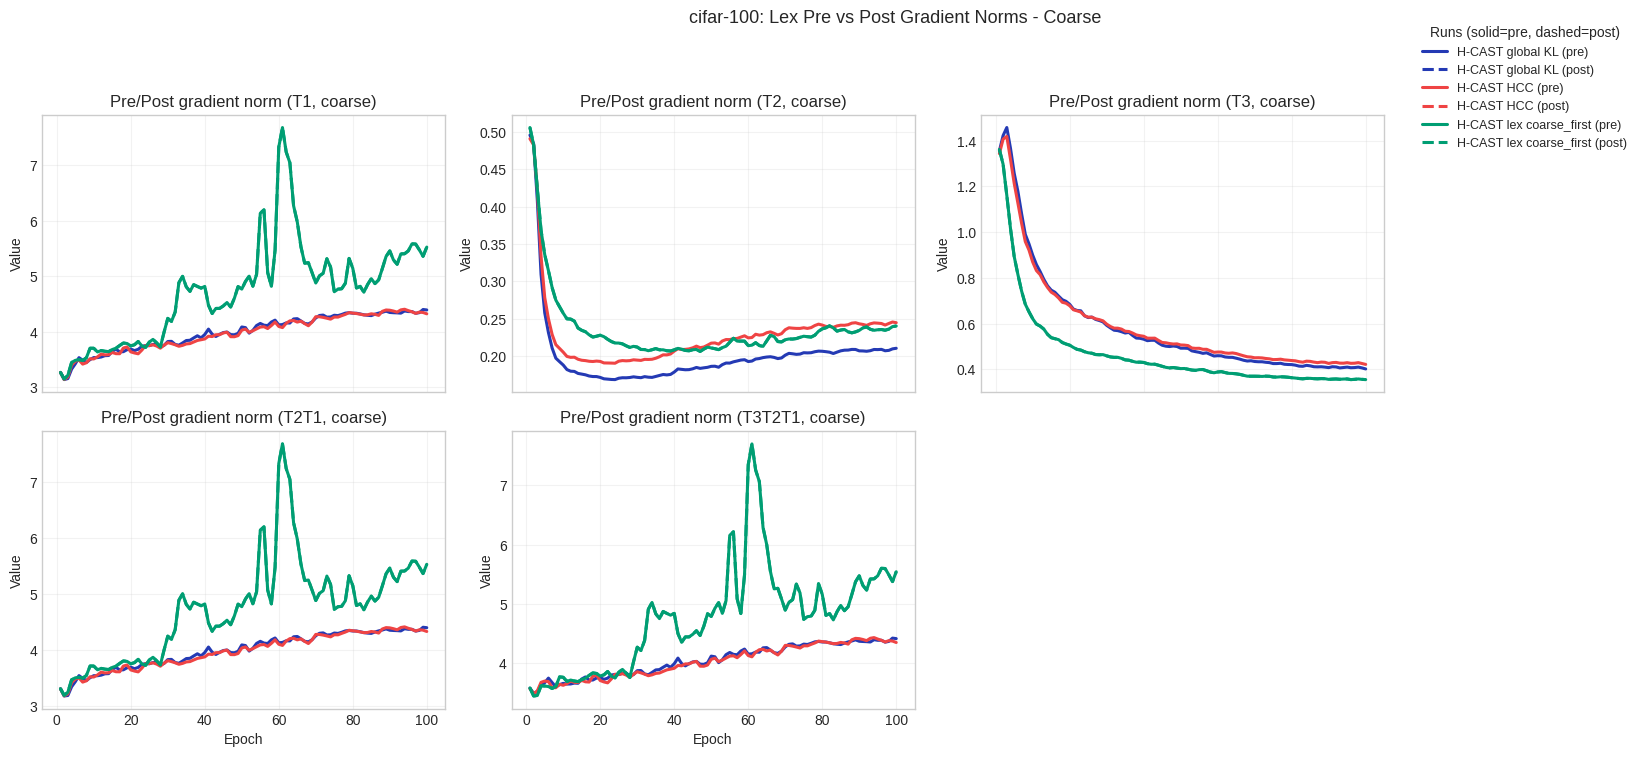

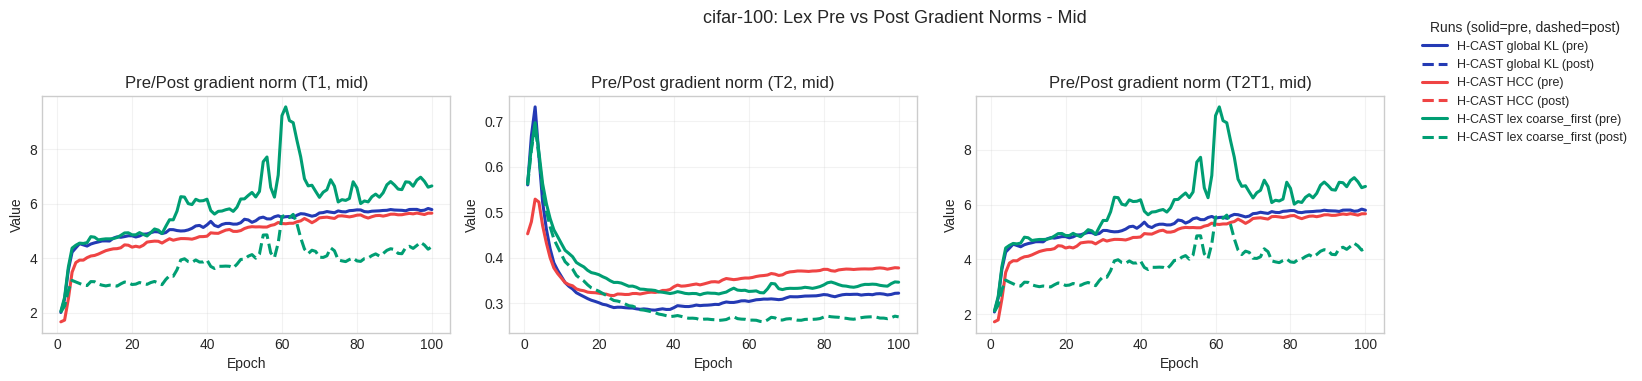

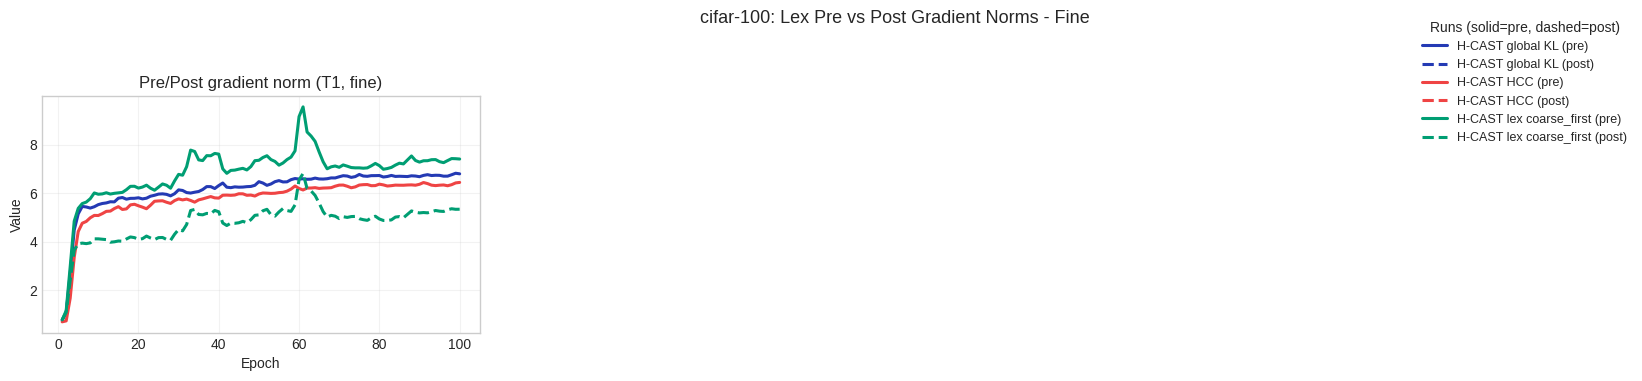

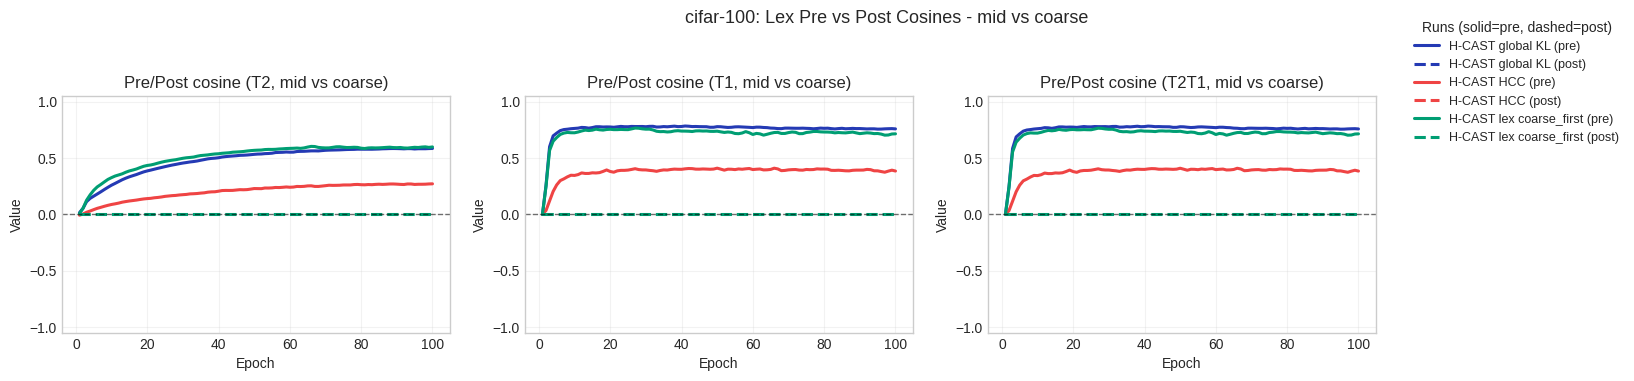

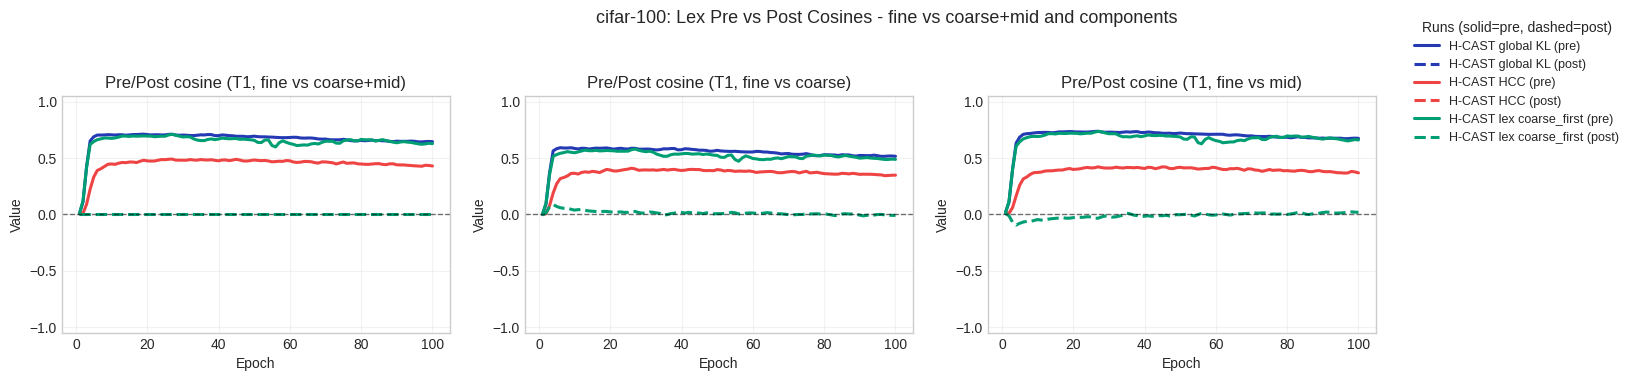

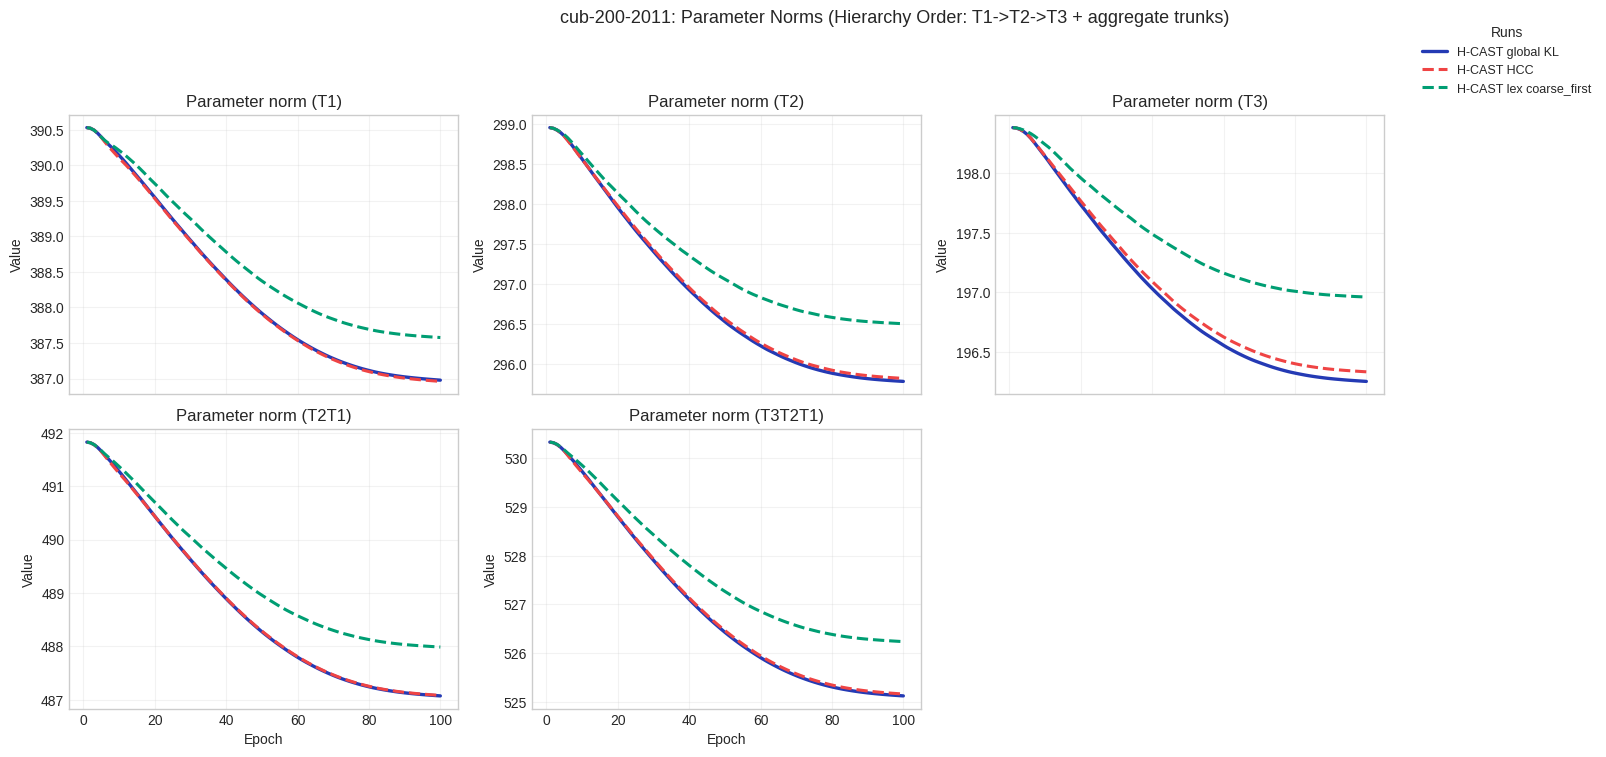

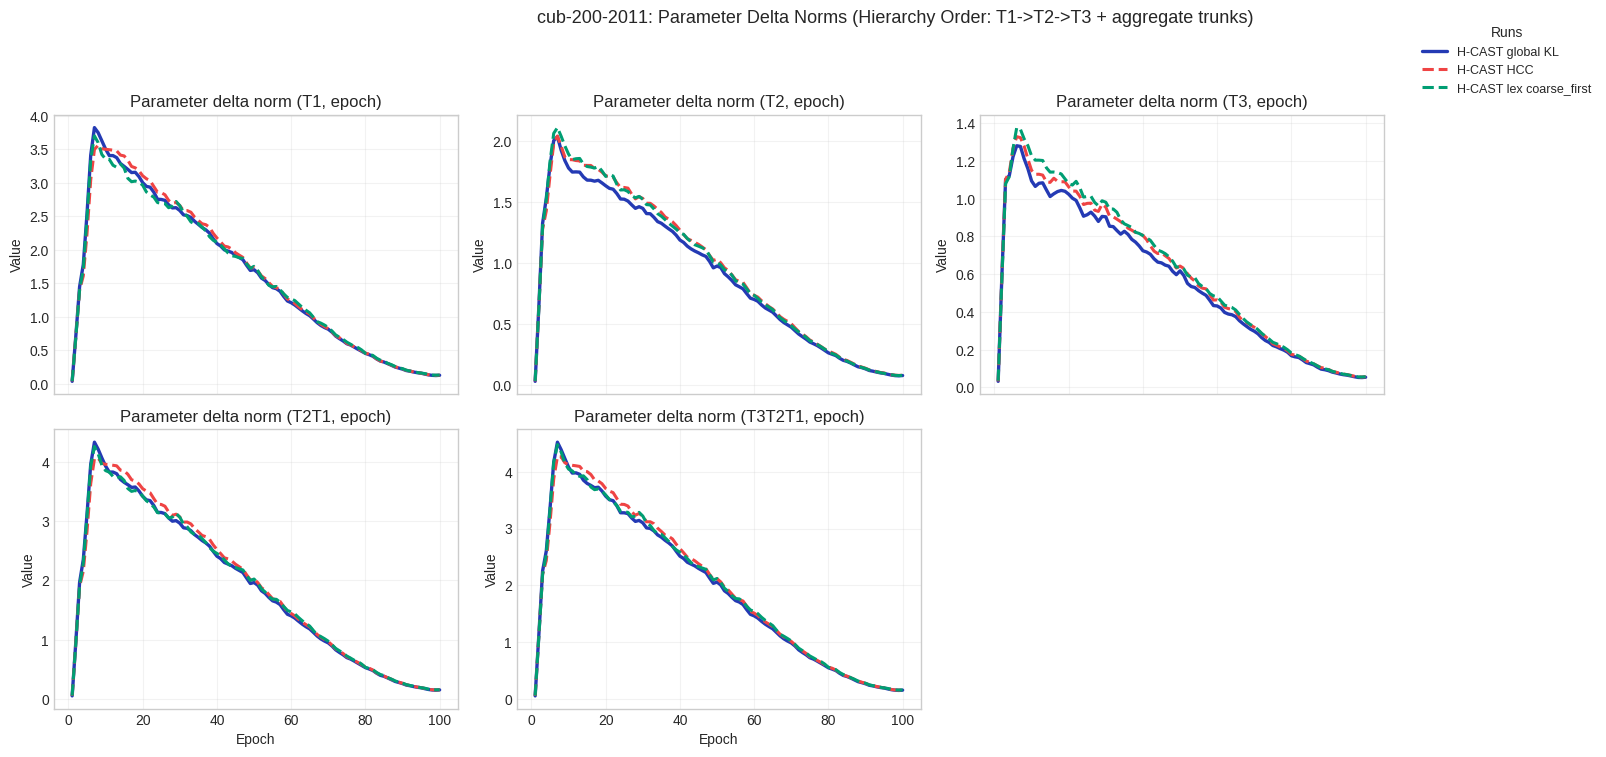

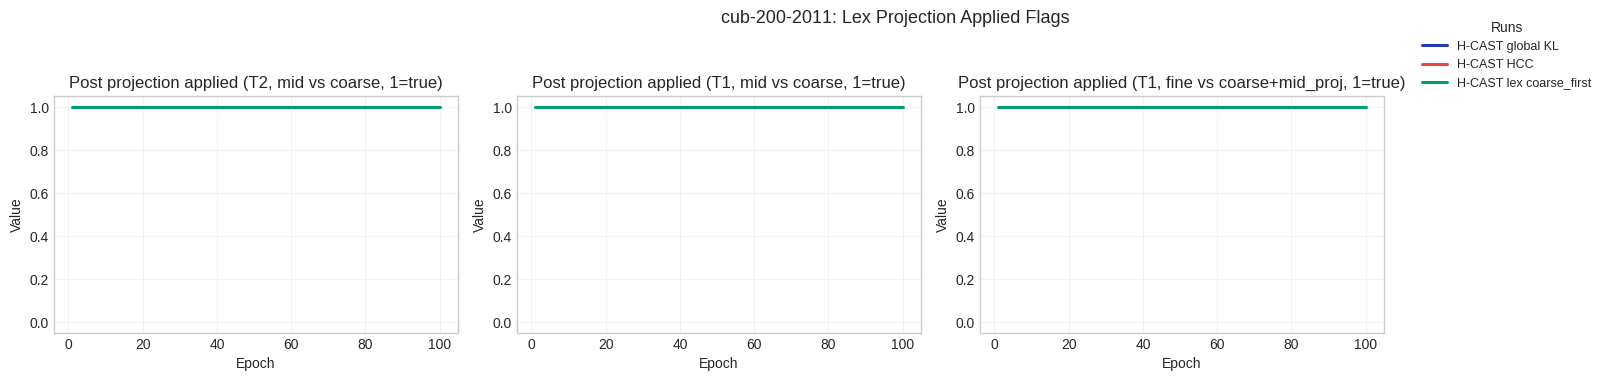

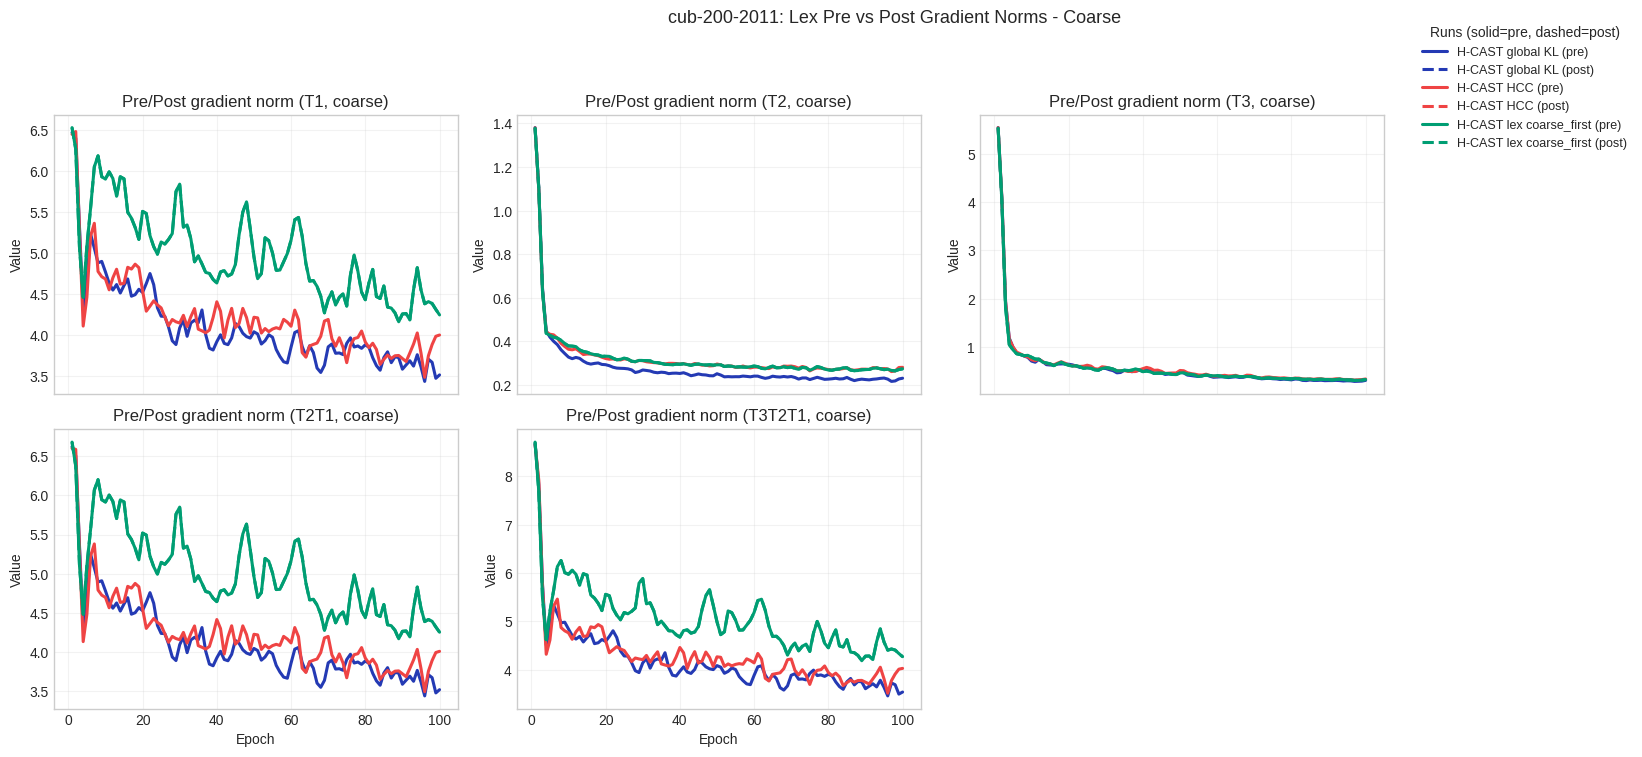

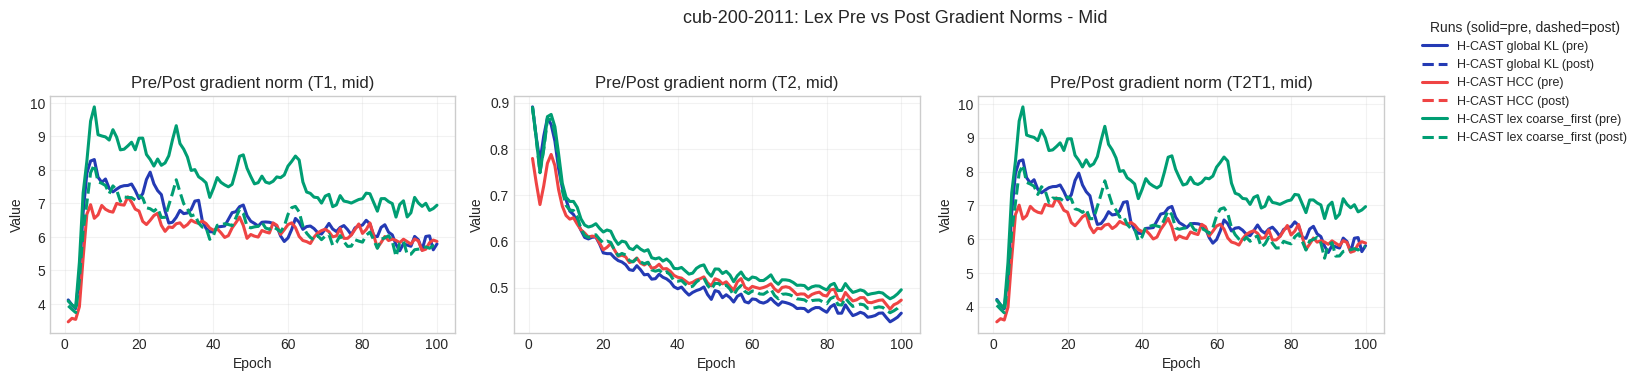

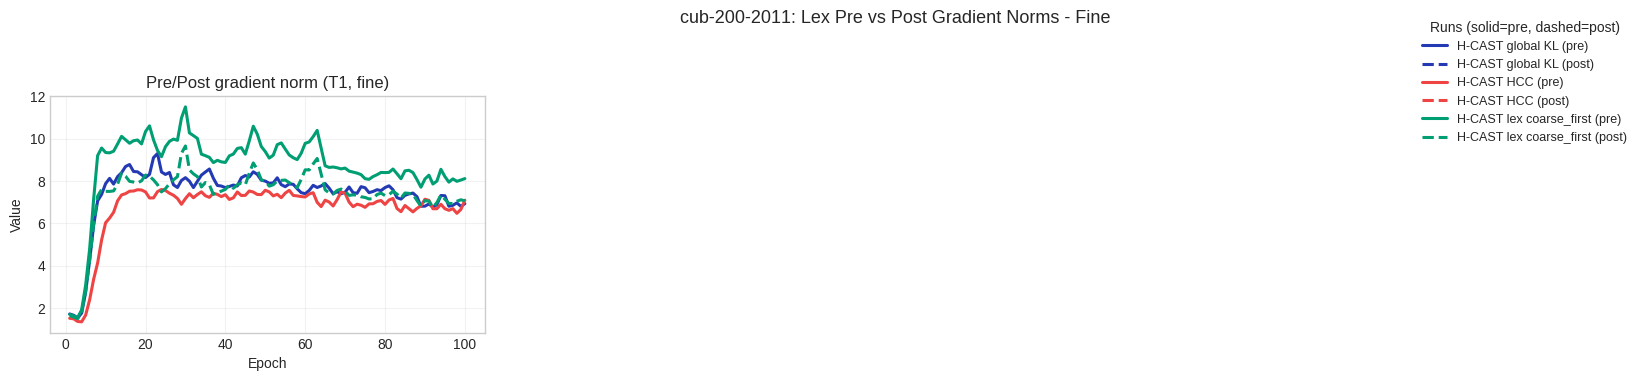

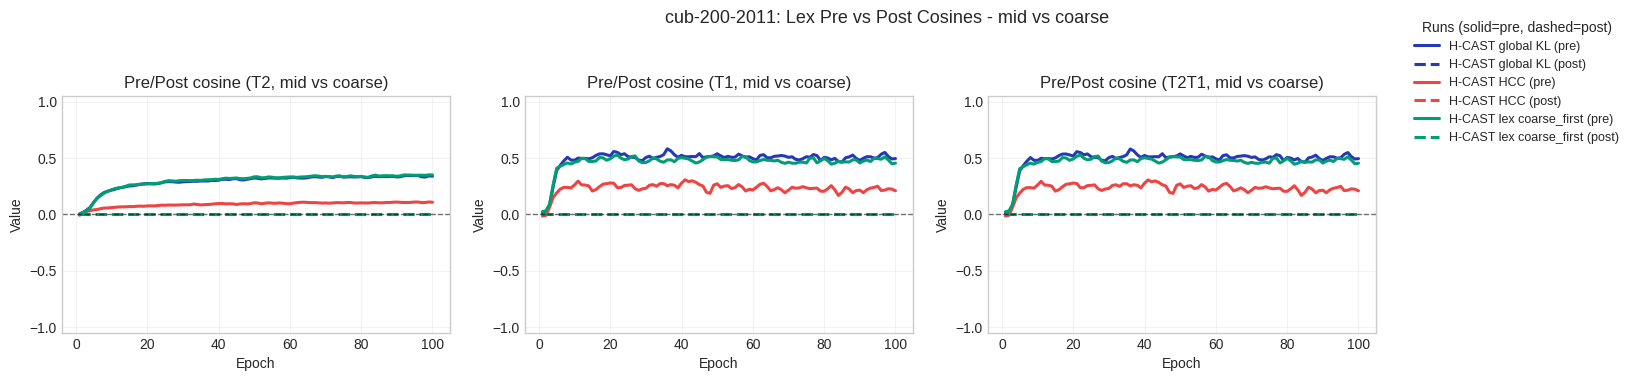

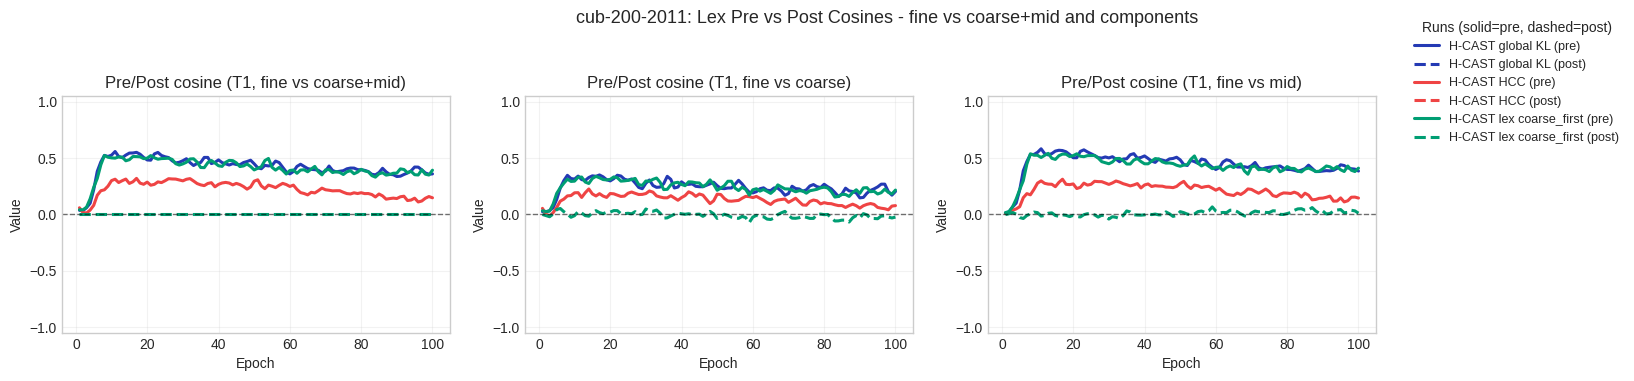

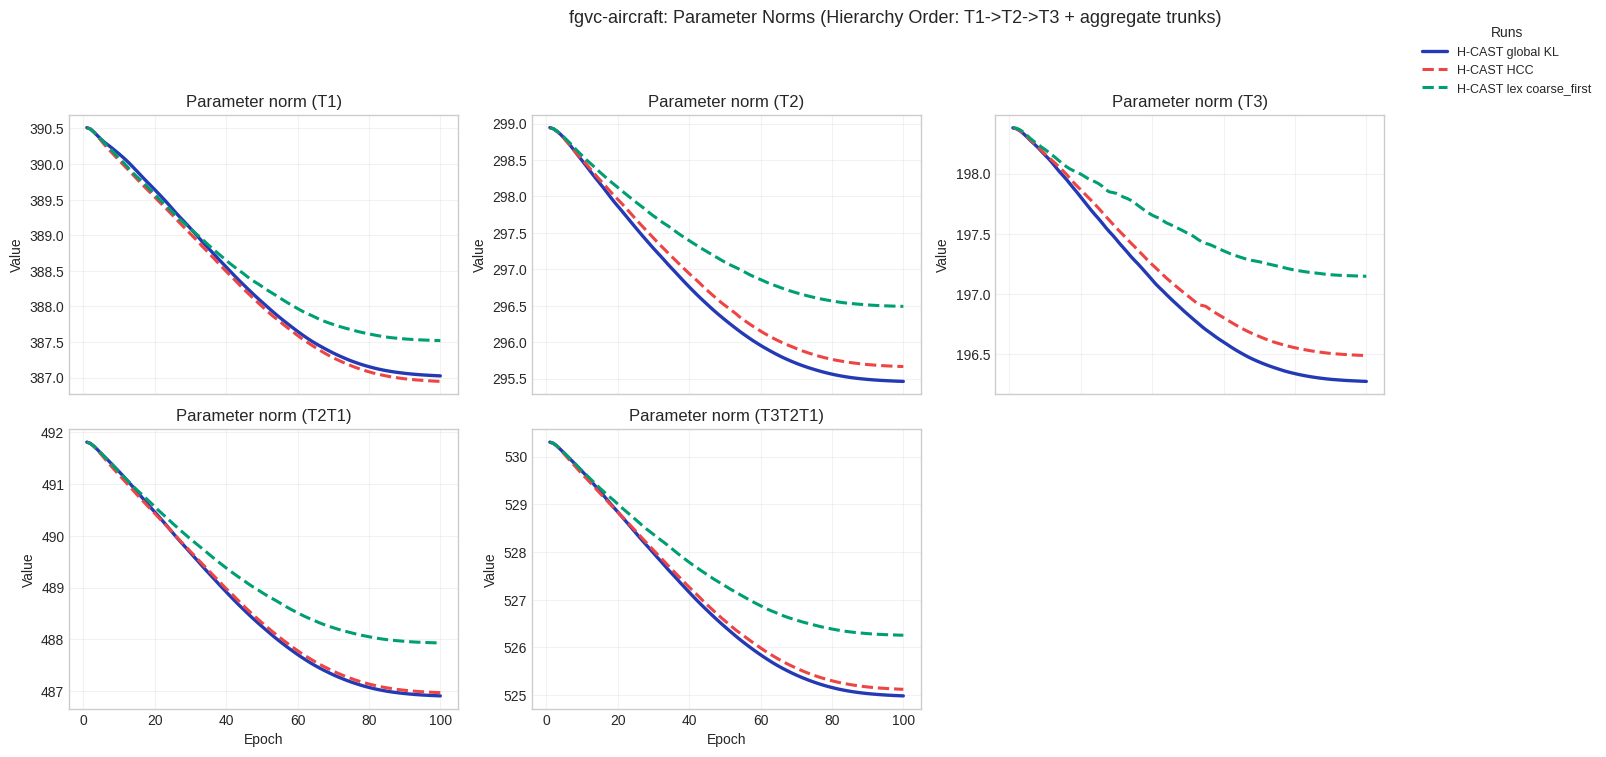

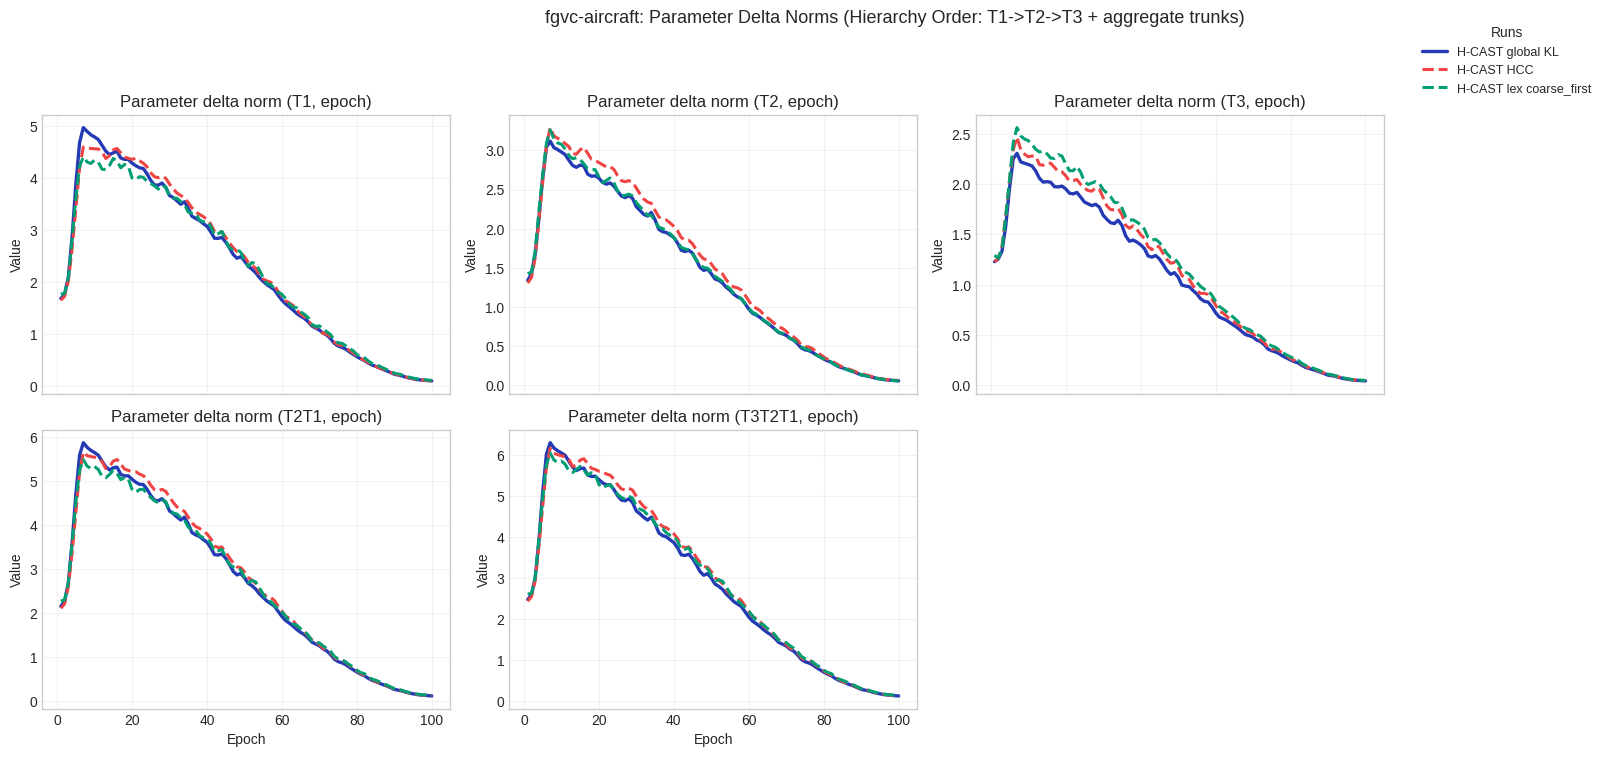

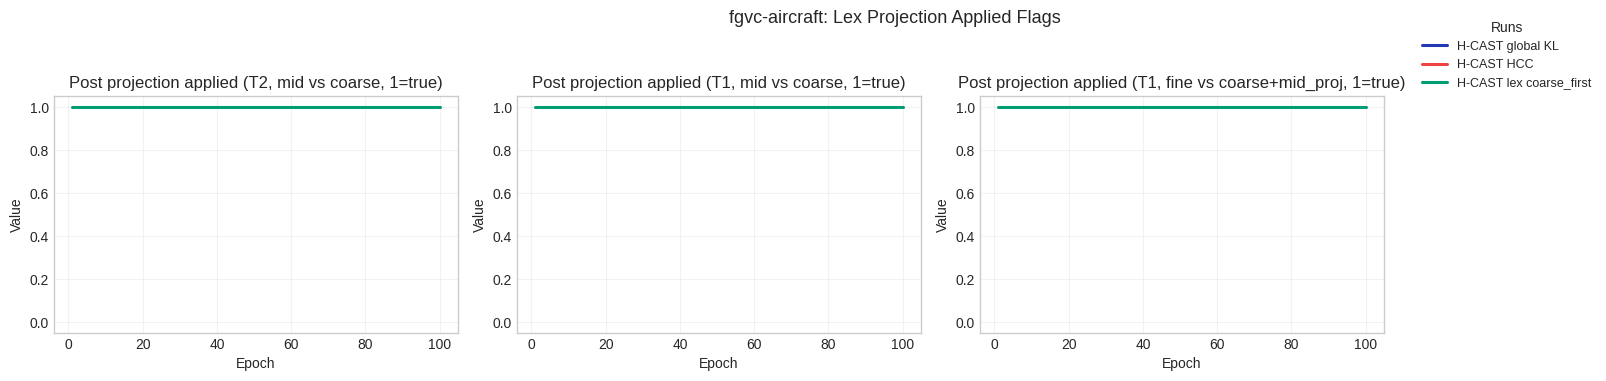

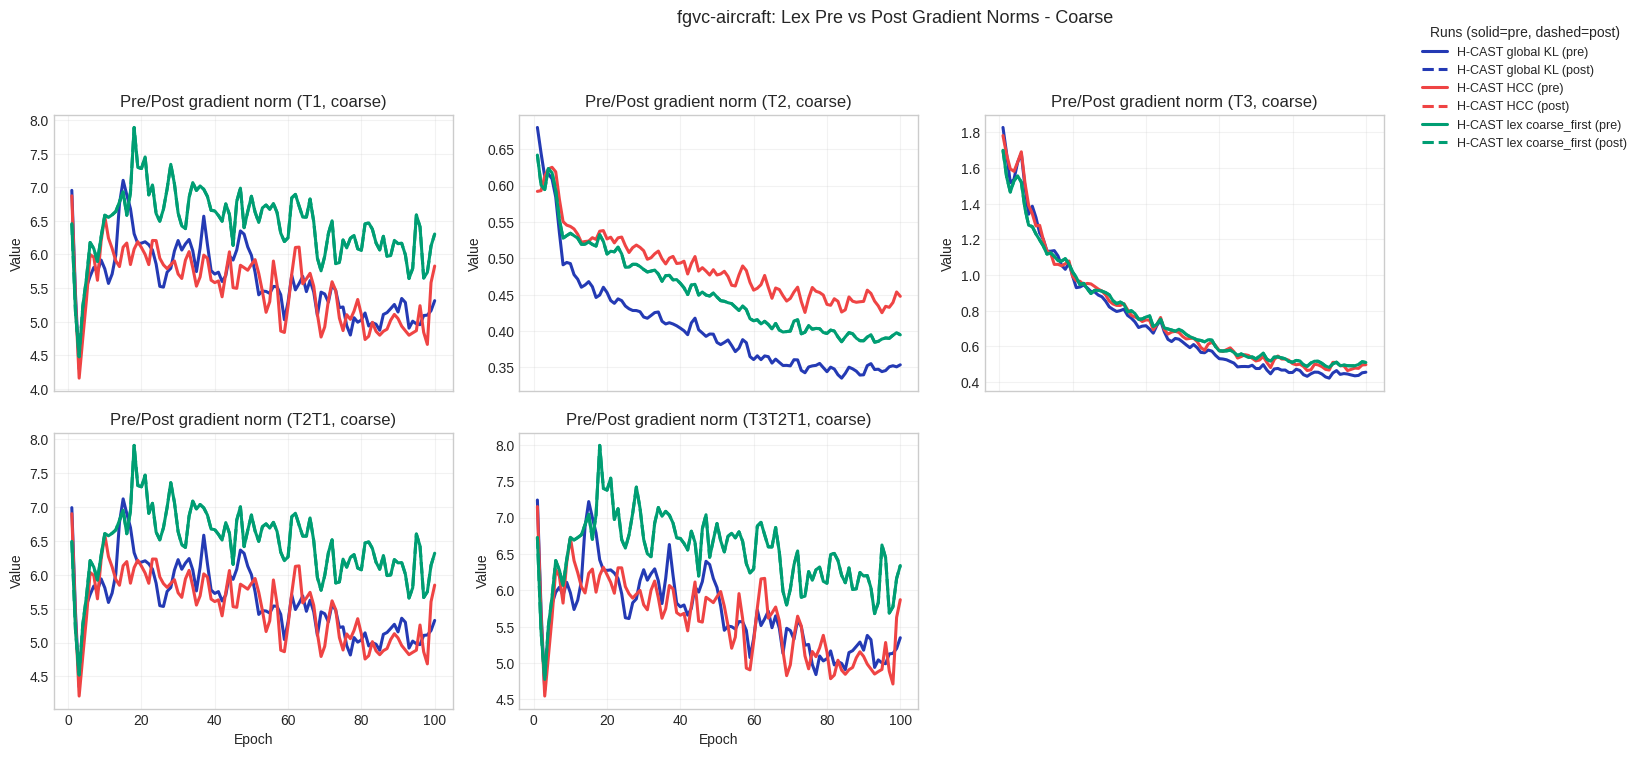

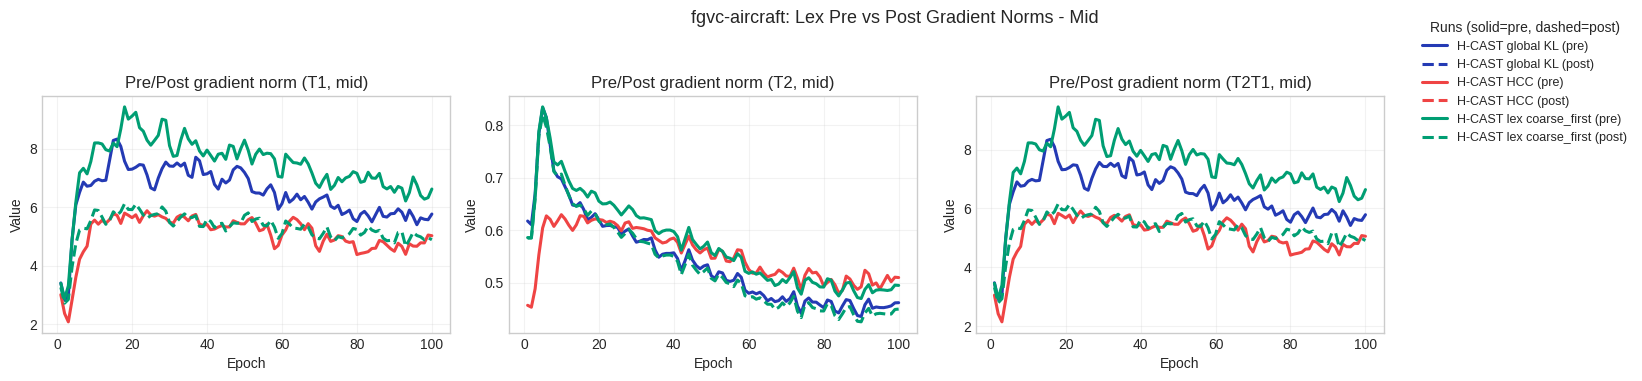

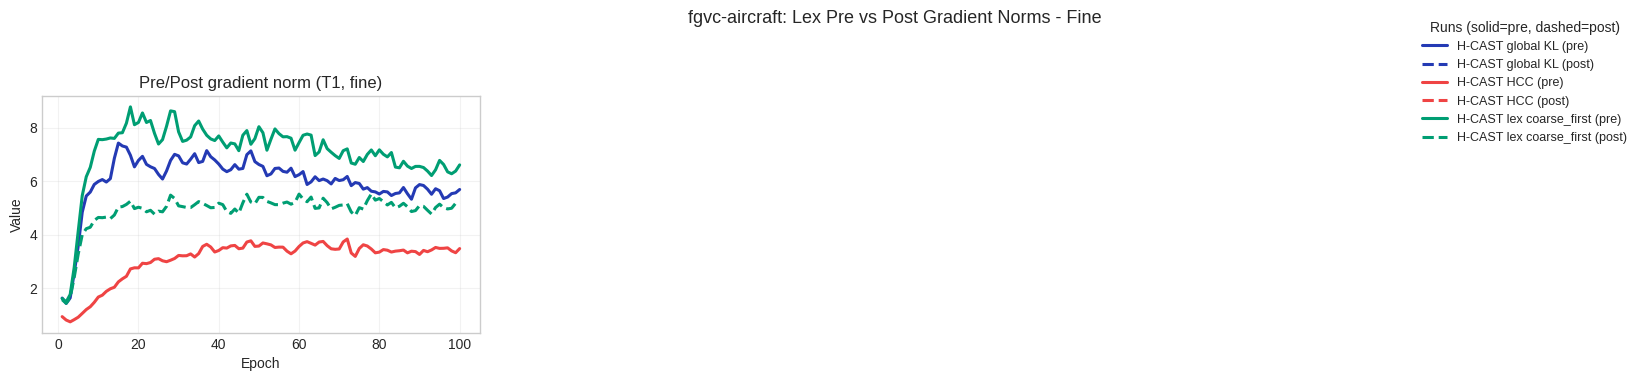

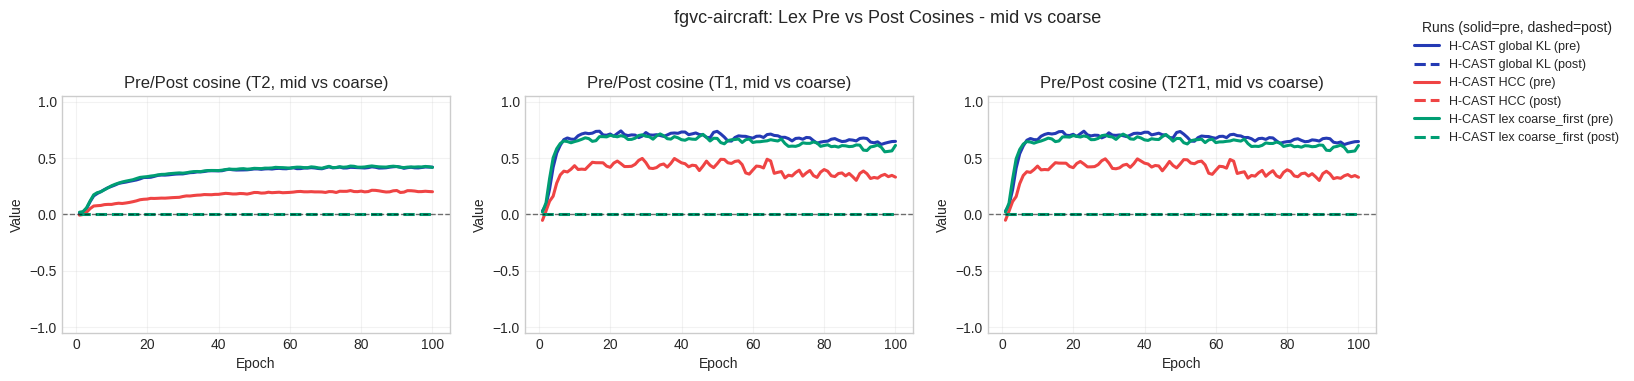

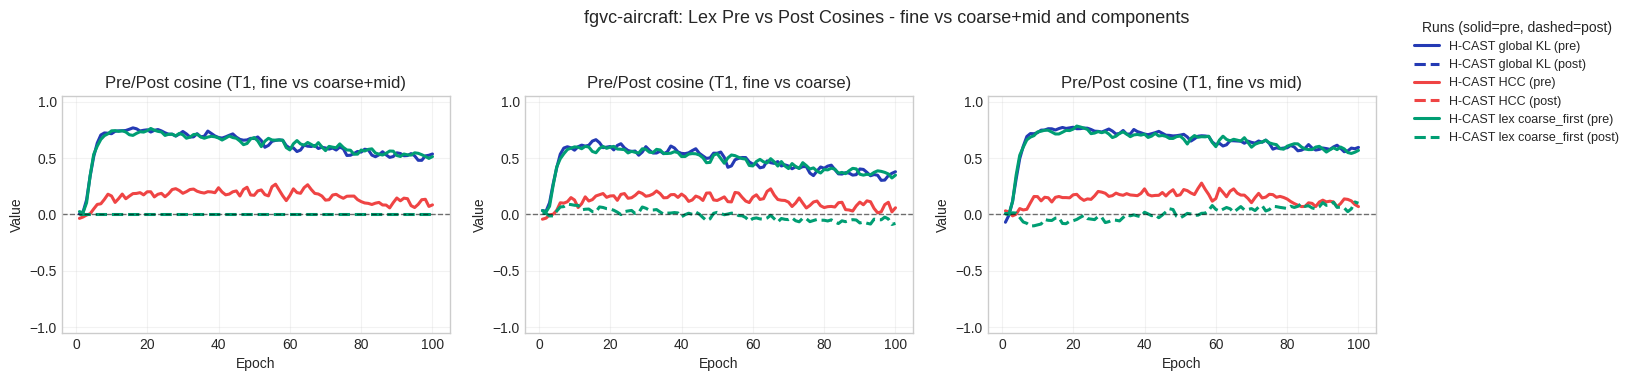

In [8]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)


Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- If `grad_norm_t1_fine` collapses while `t1` coarse/mid stay high, fine supervision is not effectively reaching shared parameters.
- Negative cosine values indicate level conflict on the corresponding subset.
- `param_norm_*` is scale, `delta_param_norm_*` is per-epoch movement.
- In lex mode, projected cosines should move near 0 (orthogonality on the target mask).
- `post_projection_applied_* = 0` means the corresponding projection step was skipped for numerical safety.


## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

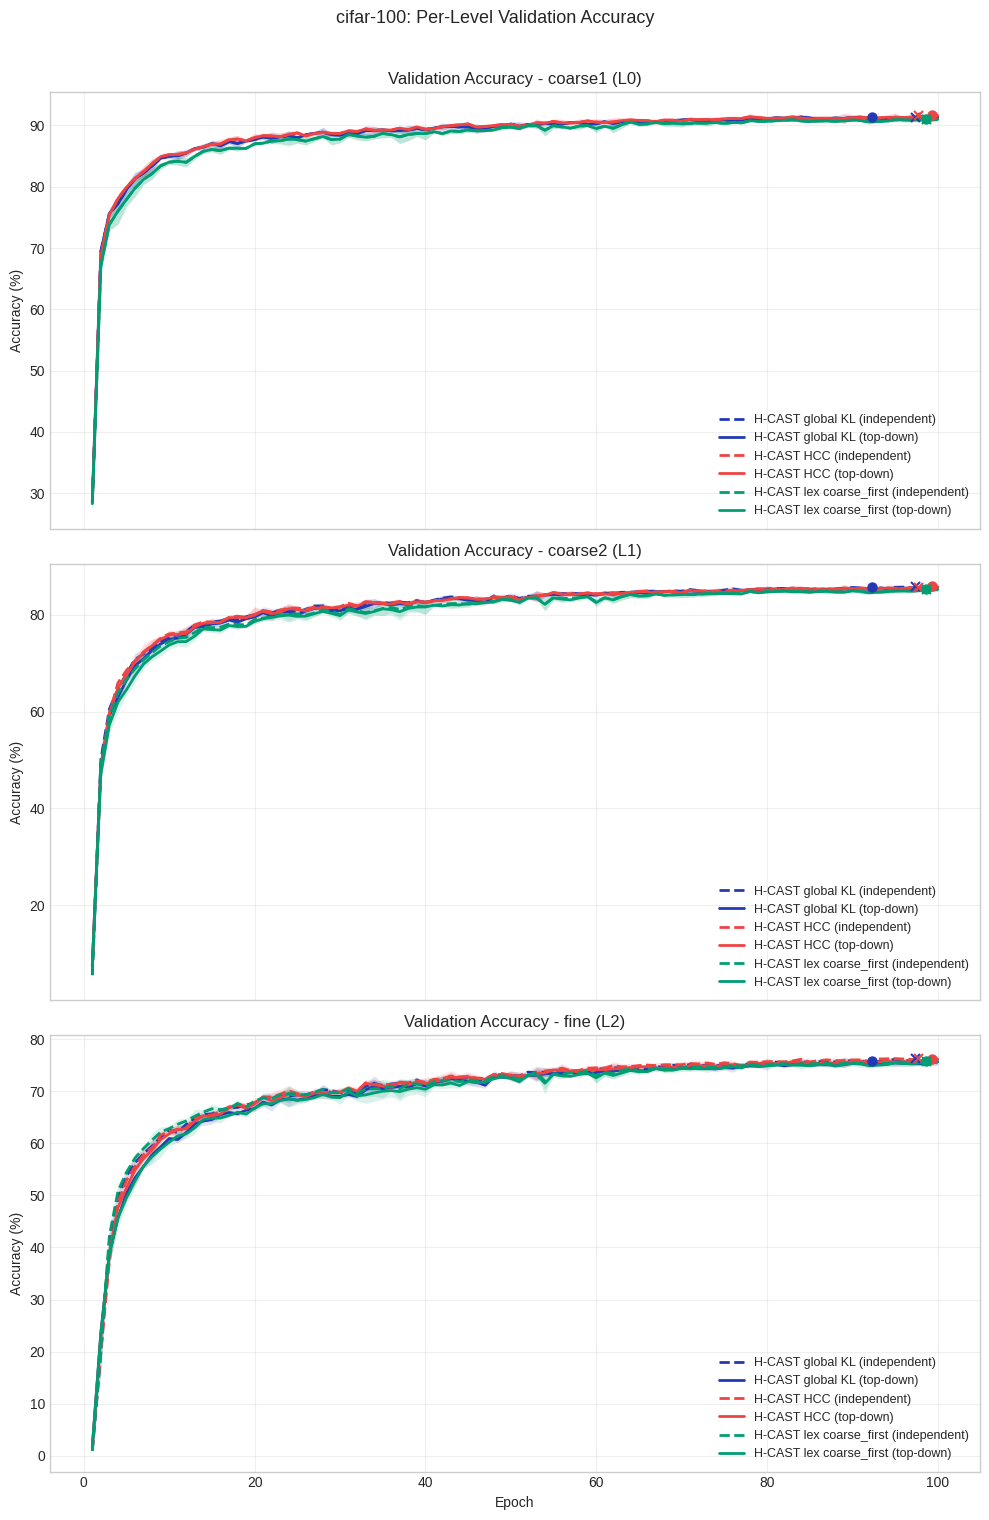

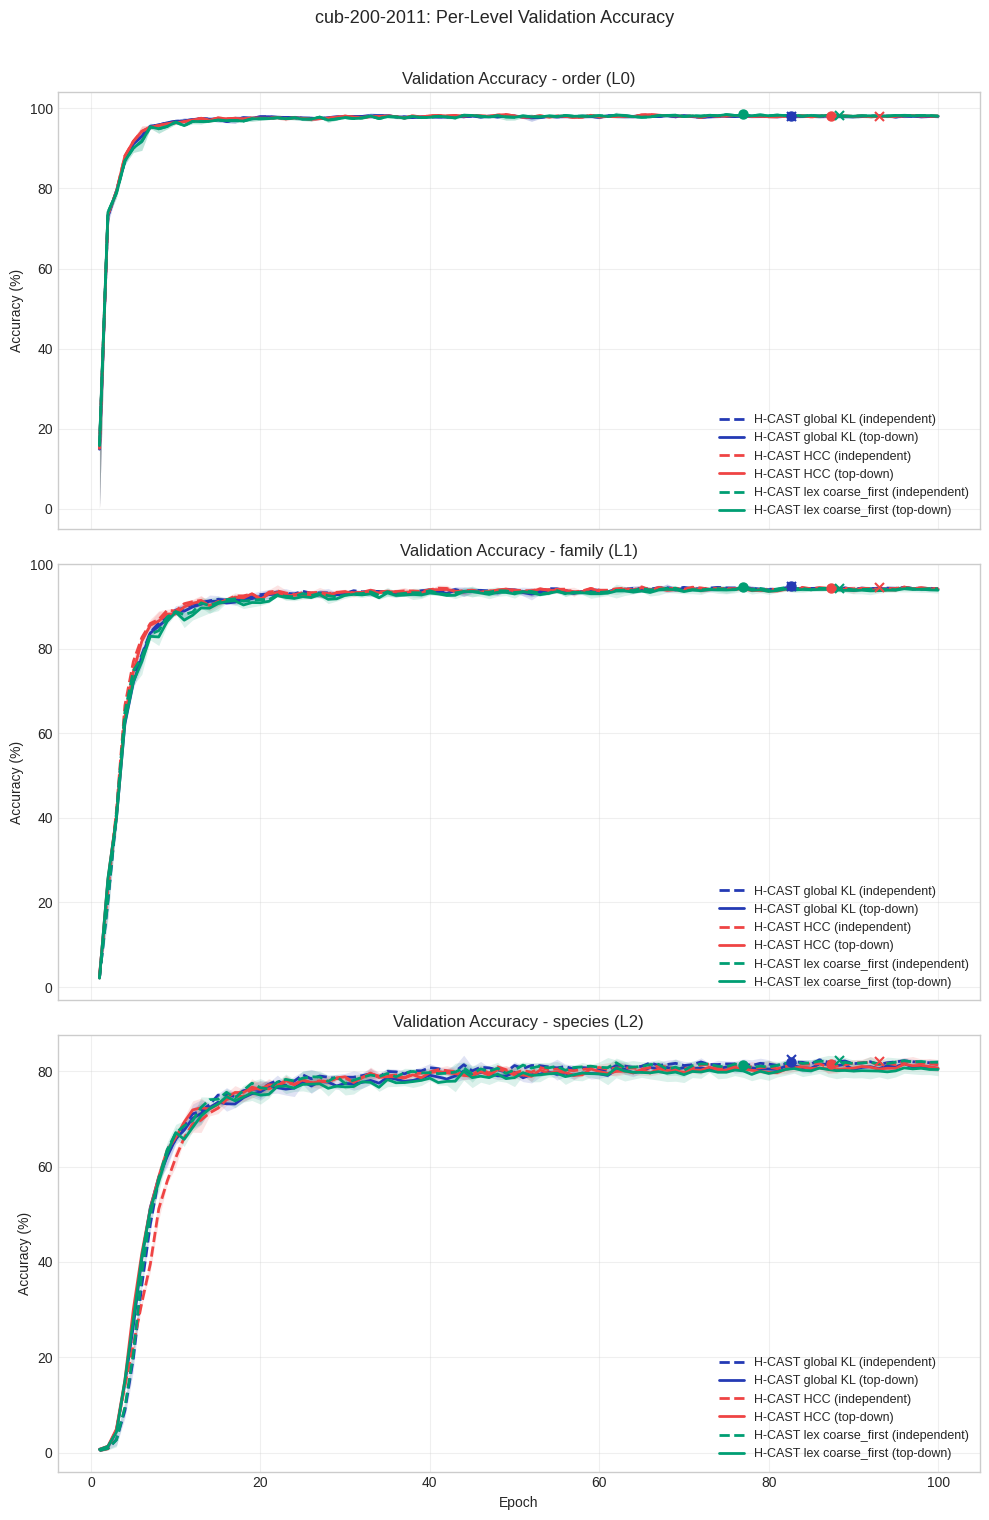

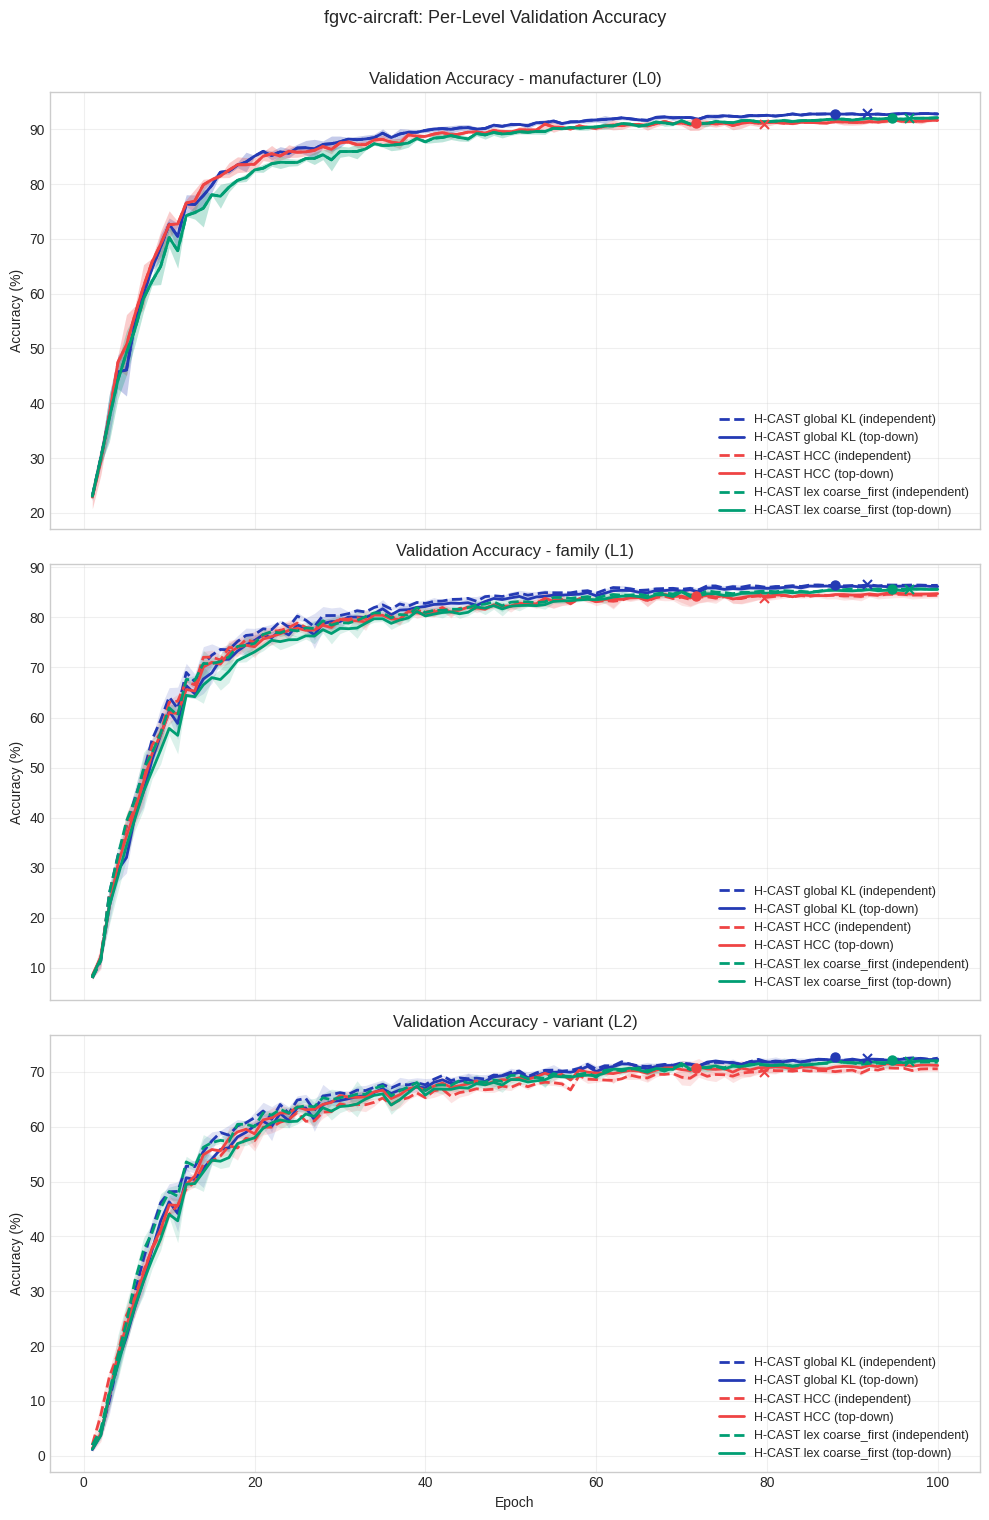

In [9]:
analysis.plot_per_level_validation_accuracy()


Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected runs and reports deltas versus the first run listed for that dataset.

In [10]:
analysis.show_final_test_tables()


### Dataset: `cifar-100`
Baseline run: **H-CAST global KL**

| Metric | H-CAST global KL (n=3) | H-CAST HCC (n=3) | H-CAST lex coarse_first (n=3) |
|---|---:|---:|---:|
| Best epoch (TD/Ind) | 92.3 ± 10.0/97.3 ± 2.3 | 99.3 ± 1.2/97.7 ± 2.5 | 98.7 ± 2.3/98.7 ± 2.3 |
| FPA independent ↑ | 73.48% ± 0.19% | <u>73.68% ± 0.32% (+0.21 pp)</u> | **74.08% ± 0.19% (+0.60 pp)** |
| FPA top-down ↑ | 75.01% ± 0.18% | **75.51% ± 0.24% (+0.50 pp)** | <u>75.45% ± 0.18% (+0.44 pp)</u> |
| wAP independent ↑ | <u>78.31% ± 0.14%</u> | **78.42% ± 0.15% (+0.11 pp)** | 78.10% ± 0.12% (-0.21 pp) |
| wAP top-down ↑ | 77.54% ± 0.17% | **77.97% ± 0.19% (+0.42 pp)** | <u>77.89% ± 0.18% (+0.35 pp)</u> |
| TICE independent ↓ | <u>7.61% ± 0.29%</u> | 8.11% ± 0.36% (+0.50 pp) | **5.87% ± 0.08% (-1.75 pp)** |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% ± 0.00% (+0.00 pp)** | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | 0.511 ± 0.008 | <u>0.510 ± 0.004 (-0.001)</u> | **0.507 ± 0.005 (-0.004)** |
| AHD top-down ↓ | 0.493 ± 0.006 | **0.486 ± 0.003 (-0.007)** | <u>0.489 ± 0.005 (-0.004)</u> |
| Acc independent coarse1 (L0) ↑ | **90.82% ± 0.32%** | <u>90.71% ± 0.06% (-0.11 pp)</u> | 90.61% ± 0.17% (-0.21 pp) |
| Acc top-down coarse1 (L0) ↑ | **90.74% ± 0.25%** | <u>90.71% ± 0.06% (-0.03 pp)</u> | 90.61% ± 0.17% (-0.13 pp) |
| Acc independent coarse2 (L1) ↑ | <u>85.20% ± 0.39%</u> | **85.22% ± 0.09% (+0.01 pp)** | 85.02% ± 0.23% (-0.19 pp) |
| Acc top-down coarse2 (L1) ↑ | 84.92% ± 0.33% | **85.14% ± 0.11% (+0.23 pp)** | <u>85.01% ± 0.17% (+0.10 pp)</u> |
| Acc independent fine (L2) ↑ | <u>75.94% ± 0.20%</u> | **76.08% ± 0.20% (+0.14 pp)** | 75.72% ± 0.10% (-0.22 pp) |
| Acc top-down fine (L2) ↑ | 75.01% ± 0.18% | **75.51% ± 0.24% (+0.50 pp)** | <u>75.45% ± 0.18% (+0.44 pp)</u> |

### Dataset: `cub-200-2011`
Baseline run: **H-CAST global KL**

| Metric | H-CAST global KL (n=3) | H-CAST HCC (n=3) | H-CAST lex coarse_first (n=3) |
|---|---:|---:|---:|
| Best epoch (TD/Ind) | 82.7 ± 14.0/82.7 ± 14.0 | 87.3 ± 17.7/93.0 ± 7.9 | 77.0 ± 13.1/88.3 ± 6.8 |
| FPA independent ↑ | **81.27% ± 0.33%** | 80.34% ± 0.17% (-0.93 pp) | <u>80.95% ± 0.35% (-0.32 pp)</u> |
| FPA top-down ↑ | **82.68% ± 0.15%** | <u>82.32% ± 0.14% (-0.36 pp)</u> | 82.02% ± 0.23% (-0.66 pp) |
| wAP independent ↑ | **85.59% ± 0.13%** | 84.89% ± 0.11% (-0.70 pp) | <u>85.49% ± 0.29% (-0.10 pp)</u> |
| wAP top-down ↑ | **85.26% ± 0.12%** | <u>84.98% ± 0.15% (-0.28 pp)</u> | 84.67% ± 0.18% (-0.59 pp) |
| TICE independent ↓ | **5.24% ± 0.41%** | 6.22% ± 0.20% (+0.98 pp) | <u>5.61% ± 0.05% (+0.37 pp)</u> |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% ± 0.00% (+0.00 pp)** | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | **0.262 ± 0.002** | 0.272 ± 0.005 (+0.010) | <u>0.270 ± 0.005 (+0.008)</u> |
| AHD top-down ↓ | **0.245 ± 0.001** | <u>0.248 ± 0.004 (+0.003)</u> | 0.257 ± 0.002 (+0.012) |
| Acc independent order (L0) ↑ | <u>98.49% ± 0.14%</u> | **98.52% ± 0.05% (+0.03 pp)** | 98.33% ± 0.04% (-0.16 pp) |
| Acc top-down order (L0) ↑ | <u>98.49% ± 0.14%</u> | **98.55% ± 0.10% (+0.06 pp)** | 98.35% ± 0.05% (-0.14 pp) |
| Acc independent family (L1) ↑ | **94.36% ± 0.11%** | <u>94.25% ± 0.30% (-0.11 pp)</u> | 94.09% ± 0.22% (-0.27 pp) |
| Acc top-down family (L1) ↑ | <u>94.29% ± 0.06%</u> | **94.33% ± 0.26% (+0.03 pp)** | 93.94% ± 0.04% (-0.36 pp) |
| Acc independent species (L2) ↑ | **83.09% ± 0.16%** | 82.23% ± 0.14% (-0.86 pp) | <u>83.02% ± 0.34% (-0.06 pp)</u> |
| Acc top-down species (L2) ↑ | **82.68% ± 0.15%** | <u>82.32% ± 0.14% (-0.36 pp)</u> | 82.02% ± 0.23% (-0.66 pp) |

### Dataset: `fgvc-aircraft`
Baseline run: **H-CAST global KL**

| Metric | H-CAST global KL (n=3) | H-CAST HCC (n=3) | H-CAST lex coarse_first (n=3) |
|---|---:|---:|---:|
| Best epoch (TD/Ind) | 88.0 ± 7.2/91.7 ± 5.5 | 83.5 ± 16.3/95.0 ± 1.4 | 94.7 ± 5.9/96.7 ± 4.2 |
| FPA independent ↑ | **70.73% ± 1.04%** | 69.59% ± 0.11% (-1.14 pp) | <u>69.61% ± 0.70% (-1.12 pp)</u> |
| FPA top-down ↑ | **73.47% ± 0.92%** | 72.17% ± 1.55% (-1.30 pp) | <u>72.42% ± 0.79% (-1.05 pp)</u> |
| wAP independent ↑ | **81.09% ± 0.61%** | 79.52% ± 0.00% (-1.58 pp) | <u>80.12% ± 0.50% (-0.98 pp)</u> |
| wAP top-down ↑ | **81.30% ± 0.67%** | 79.83% ± 1.22% (-1.48 pp) | <u>80.18% ± 0.61% (-1.12 pp)</u> |
| TICE independent ↓ | **9.09% ± 0.10%** | 10.10% ± 0.11% (+1.01 pp) | <u>9.74% ± 0.36% (+0.65 pp)</u> |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% ± 0.00% (+0.00 pp)** | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | **0.492 ± 0.013** | 0.532 ± 0.008 (+0.040) | <u>0.528 ± 0.012 (+0.037)</u> |
| AHD top-down ↓ | **0.459 ± 0.016** | 0.502 ± 0.032 (+0.043) | <u>0.490 ± 0.016 (+0.032)</u> |
| Acc independent manufacturer (L0) ↑ | **93.31% ± 0.12%** | 92.32% ± 0.38% (-0.99 pp) | <u>92.54% ± 0.15% (-0.77 pp)</u> |
| Acc top-down manufacturer (L0) ↑ | **93.30% ± 0.18%** | 92.21% ± 0.62% (-1.09 pp) | <u>92.57% ± 0.30% (-0.73 pp)</u> |
| Acc independent family (L1) ↑ | **87.57% ± 0.51%** | 85.66% ± 0.25% (-1.91 pp) | <u>85.95% ± 0.43% (-1.62 pp)</u> |
| Acc top-down family (L1) ↑ | **87.36% ± 0.65%** | 85.45% ± 1.02% (-1.91 pp) | <u>85.97% ± 0.49% (-1.39 pp)</u> |
| Acc independent variant (L2) ↑ | **72.90% ± 1.05%** | 71.38% ± 0.30% (-1.52 pp) | <u>72.31% ± 0.71% (-0.59 pp)</u> |
| Acc top-down variant (L2) ↑ | **73.47% ± 0.92%** | 72.17% ± 1.55% (-1.30 pp) | <u>72.42% ± 0.79% (-1.05 pp)</u> |

Interpretation note:
- Metrics are rows and runs are columns.
- Goal arrows are in metric names: `↑` means maximize, `↓` means minimize.
- Non-baseline run cells show `value (delta vs baseline)`.
- Bold cells mark the best run for each metric in the dataset table.
- Delta is computed as `run - baseline`.
